# 14-Day Injury Risk Model for Elite Football Players
## A Rigorous, Decision-Oriented Analysis

**Objective:** Estimate the probability that an elite male footballer sustains a time-loss injury within the next 14 days, using only publicly available data.

**Key principle:** This notebook prioritises *honest, operationally useful* conclusions over impressive-looking metrics. If the model cannot support real-world alerting, we will say so explicitly.

---
# 1. Executive Summary

This notebook attempts to build a daily injury-risk model for elite football players using publicly available data from Transfermarkt (injury records, match appearances, player profiles).

**Spoiler (to be updated after modeling):** The analysis will reveal whether the available feature set — predominantly match-exposure workload proxies and injury history — contains enough signal to produce an operationally useful alerting system, or whether it merely captures base-rate variation that cannot meaningfully separate high-risk from low-risk player-days.

---
# 2. Business Framing and Success Criteria

## Problem Statement (Professional Terms)

| Dimension | Definition |
|---|---|
| **Unit of prediction** | Player-day (one row per player per calendar day) |
| **Target** | Binary: will this player sustain a time-loss injury in the next 1–14 days? |
| **Forecast horizon** | 14 days (rolling daily prediction) |
| **Operational user** | Club medical/performance staff making load-management decisions |
| **Decision triggered** | Reduce training load, rest player, trigger screening, modify match selection |

## Who would use this model?
Sports science and medical departments at elite football clubs. They need actionable daily risk scores to prioritise which players get additional screening, reduced load, or tactical rest.

## What action follows a high-risk prediction?
- Flag player for enhanced medical screening
- Reduce training intensity/volume
- Consider tactical rotation or substitution planning
- Communicate risk to coaching staff for match-day decisions

## What false-positive rate is tolerable?
A medical staff of ~5 people managing a squad of ~25 players cannot meaningfully respond to more than **3–5 high-risk alerts per week**. If the model flags 10+ players daily, it is operationally useless regardless of recall.

## What does "good enough" mean?
- The model must beat a simple "flag all players who played 3+ matches in 7 days" heuristic
- At a tolerable alert volume (~3–5/week), precision should be meaningfully above the base rate
- Predicted probabilities should be roughly calibrated (not just rank-ordered)
- Performance must be stable across seasons, not just one lucky test split

---
# 3. Data Audit

We audit every source table before any joins or transformations.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data')
TM_DIR = DATA_DIR / 'transfermarkt'
TMD_DIR = DATA_DIR / 'transfermarkt-datasets'

print("Loading source tables...")

# --- Source 1: Injury history ---
injuries = pd.read_csv(TM_DIR / 'player_injuries' / 'player_injuries.csv')

# --- Source 2: Player profiles (demographics) ---
profiles = pd.read_csv(TM_DIR / 'player_profiles' / 'player_profiles.csv')

# --- Source 3: Appearances (match-level exposure) ---
appearances = pd.read_csv(TMD_DIR / 'appearances.csv.gz')

# --- Source 4: Games (match metadata) ---
games = pd.read_csv(TMD_DIR / 'games.csv.gz')

# --- Source 5: Players (demographics from transfermarkt-datasets) ---
players = pd.read_csv(TMD_DIR / 'players.csv.gz')

print("All tables loaded.")
print(f"  injuries:    {injuries.shape}")
print(f"  profiles:    {profiles.shape}")
print(f"  appearances: {appearances.shape}")
print(f"  games:       {games.shape}")
print(f"  players:     {players.shape}")

Loading source tables...
All tables loaded.
  injuries:    (143195, 7)
  profiles:    (92671, 34)
  appearances: (1734466, 13)
  games:       (79797, 23)
  players:     (33789, 23)


## 3.1 Injuries Table Audit

In [2]:
print("=== INJURIES TABLE ===")
print(f"Shape: {injuries.shape}")
print(f"\nColumns: {list(injuries.columns)}")
print(f"\nDtypes:\n{injuries.dtypes}")
print(f"\nMissingness:")
miss = injuries.isnull().sum()
miss_pct = (miss / len(injuries) * 100).round(2)
display(pd.DataFrame({'missing': miss, 'pct': miss_pct}).query('missing > 0').sort_values('pct', ascending=False))

print(f"\nDuplicate rows: {injuries.duplicated().sum()}")
print(f"Unique players: {injuries['player_id'].nunique()}")
print(f"\nSample rows:")
display(injuries.head(10))

print(f"\nInjury reason value counts (top 30):")
display(injuries['injury_reason'].value_counts().head(30))

print(f"\nSeason coverage:")
display(injuries['season_name'].value_counts().sort_index())

print(f"\nDate range: {injuries['from_date'].min()} to {injuries['from_date'].max()}")
print(f"End date range: {injuries['end_date'].min()} to {injuries['end_date'].max()}")

print(f"\nDays missed stats:")
display(injuries['days_missed'].describe())

=== INJURIES TABLE ===
Shape: (143195, 7)

Columns: ['player_id', 'season_name', 'injury_reason', 'from_date', 'end_date', 'days_missed', 'games_missed']

Dtypes:
player_id          int64
season_name          str
injury_reason        str
from_date            str
end_date             str
days_missed      float64
games_missed       int64
dtype: object

Missingness:


,missing,pct
end_date,1523,1.0600
from_date,22,0.0200
days_missed,22,0.0200



Duplicate rows: 111
Unique players: 34561

Sample rows:


,player_id,season_name,injury_reason,from_date,end_date,days_missed,games_missed
0,10,15/16,Hand injury,2016-04-19,2016-04-29,11.0000,2
1,10,15/16,Thigh problems,2015-12-18,2015-12-31,14.0000,1
2,10,15/16,Capsular injury,2015-11-11,2015-11-21,11.0000,0
3,10,15/16,Rest,2015-11-04,2015-11-06,3.0000,1
4,10,15/16,Hamstring injury,2015-08-20,2015-10-08,50.0000,10
5,10,14/15,Lumbago,2014-12-02,2014-12-04,3.0000,1
6,10,13/14,muscular problems,2014-04-06,2014-05-03,28.0000,4
7,10,13/14,Back problems,2014-03-23,2014-03-29,7.0000,2
8,10,13/14,Pelvic injury,2014-02-27,2014-03-05,7.0000,3
9,10,13/14,cold,2014-01-27,2014-02-01,6.0000,1



Injury reason value counts (top 30):


injury_reason
unknown injury            27028
Muscle injury              6433
Hamstring injury           5786
Knee injury                5544
muscular problems          4880
Ankle injury               4602
Cruciate ligament tear     4035
Ill                        3694
Corona virus               3469
Knock                      2991
Knee problems              2908
Torn muscle fiber          2662
Thigh problems             2628
Fitness                    2606
Shoulder injury            2142
Calf injury                1884
Adductor pain              1559
Foot injury                1509
Adductor injury            1374
Groin injury               1303
Hamstring strain           1280
Knee surgery               1253
Rest                       1206
flu                        1153
Back problems              1142
Calf problems              1075
minor knock                1005
Meniscus injury             942
Leg injury                  925
Muscle fatigue              829
Name: count, dtype: int64


Season coverage:


season_name
00/01        218
01/02        250
02/03        253
03/04        277
04/05        348
05/06        337
06/07        397
07/08       1386
08/09       1993
09/10       1772
10/11       2417
11/12       2835
12/13       3399
13/14       4145
14/15       4689
15/16       5816
16/17       7596
17/18       8734
18/19      10463
19/20      10372
1909/10        5
1910/11        2
20/21      14058
21/22      14885
22/23      14296
23/24      14483
24/25      15102
25/26       2108
73/74          2
74/75          3
75/76          2
80/81          3
81/82          1
82/83          1
83/84          3
89/90          5
90/91          3
91/92          5
92/93          6
93/94         22
94/95         23
95/96         47
96/97         65
97/98         84
98/99        124
99/00        160
Name: count, dtype: int64


Date range: 1973-09-02 to 2025-12-22
End date range: 1973-09-06 to 2026-09-01

Days missed stats:


count   143173.0000
mean        51.7193
std        104.4372
min          1.0000
25%         10.0000
50%         22.0000
75%         53.0000
max       8655.0000
Name: days_missed, dtype: float64

## 3.2 Appearances Table Audit

In [3]:
print("=== APPEARANCES TABLE ===")
print(f"Shape: {appearances.shape}")
print(f"\nColumns: {list(appearances.columns)}")
print(f"\nDtypes:\n{appearances.dtypes}")

miss = appearances.isnull().sum()
miss_pct = (miss / len(appearances) * 100).round(2)
print(f"\nMissingness:")
display(pd.DataFrame({'missing': miss, 'pct': miss_pct}).sort_values('pct', ascending=False))

print(f"\nDuplicate rows: {appearances.duplicated().sum()}")
print(f"Unique players: {appearances['player_id'].nunique()}")
print(f"Unique games: {appearances['game_id'].nunique()}")
print(f"Date range: {appearances['date'].min()} to {appearances['date'].max()}")

print(f"\nMinutes played stats:")
display(appearances['minutes_played'].describe())

print(f"\nCompetition coverage:")
display(appearances['competition_id'].value_counts().head(15))

print(f"\nSample rows:")
display(appearances.head(5))

=== APPEARANCES TABLE ===
Shape: (1734466, 13)

Columns: ['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played']

Dtypes:
appearance_id               str
game_id                   int64
player_id                 int64
player_club_id            int64
player_current_club_id    int64
date                        str
player_name                 str
competition_id              str
yellow_cards              int64
red_cards                 int64
goals                     int64
assists                   int64
minutes_played            int64
dtype: object

Missingness:


,missing,pct
appearance_id,0,0.0000
game_id,0,0.0000
player_id,0,0.0000
player_club_id,0,0.0000
player_current_club_id,0,0.0000
date,0,0.0000
player_name,6,0.0000
competition_id,0,0.0000
yellow_cards,0,0.0000
red_cards,0,0.0000



Duplicate rows: 0
Unique players: 26261
Unique games: 67645
Date range: 2012-07-03 to 2025-07-13

Minutes played stats:


count   1734466.0000
mean         68.9263
std          30.0582
min           1.0000
25%          45.0000
50%          90.0000
75%          90.0000
max         148.0000
Name: minutes_played, dtype: float64


Competition coverage:


competition_id
IT1     143261
ES1     141924
GB1     138259
FR1     134016
TR1     123030
L1      115061
NL1     110571
PO1     110443
BE1      93594
RU1      88075
GR1      82092
SC1      75076
UKR1     68963
DK1      61172
EL       49565
Name: count, dtype: int64


Sample rows:


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45
3,2234418_73333,2234418,73333,1274,6646,2012-07-05,Vegar Hedenstad,ELQ,0,0,0,0,90
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,0,1,90


## 3.3 Players / Profiles Audit

In [4]:
print("=== PLAYERS TABLE (transfermarkt-datasets) ===")
print(f"Shape: {players.shape}")
print(f"Columns: {list(players.columns)}")

miss = players.isnull().sum()
miss_pct = (miss / len(players) * 100).round(2)
print(f"\nMissingness (top 10):")
display(pd.DataFrame({'missing': miss, 'pct': miss_pct}).sort_values('pct', ascending=False).head(10))

print(f"\nPosition distribution:")
display(players['position'].value_counts())
print(f"\nSub-position distribution:")
display(players['sub_position'].value_counts().head(15))
print(f"\nFoot distribution:")
display(players['foot'].value_counts())

print(f"\n=== PROFILES TABLE (salimt/football-datasets) ===")
print(f"Shape: {profiles.shape}")
cols_of_interest = ['player_id', 'player_name', 'date_of_birth', 'height', 'position',
                    'main_position', 'foot', 'citizenship', 'current_club_name']
print(f"\nRelevant columns: {cols_of_interest}")

miss_p = profiles[cols_of_interest].isnull().sum()
miss_pct_p = (miss_p / len(profiles) * 100).round(2)
display(pd.DataFrame({'missing': miss_p, 'pct': miss_pct_p}).sort_values('pct', ascending=False))

print(f"\nUnique player_ids: {profiles['player_id'].nunique()} (rows: {len(profiles)})")
print(f"Duplicate player_ids: {profiles['player_id'].duplicated().sum()}")

=== PLAYERS TABLE (transfermarkt-datasets) ===
Shape: (33789, 23)
Columns: ['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']

Missingness (top 10):


,missing,pct
agent_name,16383,48.4900
contract_expiration_date,12589,37.2600
country_of_birth,2826,8.3600
foot,2629,7.7800
city_of_birth,2495,7.3800
height_in_cm,2337,6.9200
highest_market_value_in_eur,2282,6.7500
market_value_in_eur,2282,6.7500
first_name,2076,6.1400
country_of_citizenship,361,1.0700



Position distribution:


position
Defender      10778
Midfield       9720
Attack         9230
Goalkeeper     3875
Missing         186
Name: count, dtype: int64


Sub-position distribution:


...


Foot distribution:


foot
right    21937
left      7807
both      1416
Name: count, dtype: int64


=== PROFILES TABLE (salimt/football-datasets) ===
Shape: (92671, 34)

Relevant columns: ['player_id', 'player_name', 'date_of_birth', 'height', 'position', 'main_position', 'foot', 'citizenship', 'current_club_name']


,missing,pct
foot,23488,25.3500
date_of_birth,1006,1.0900
player_name,520,0.5600
citizenship,57,0.0600
player_id,0,0.0000
position,2,0.0000
height,4,0.0000
main_position,2,0.0000
current_club_name,0,0.0000



Unique player_ids: 92671 (rows: 92671)
Duplicate player_ids: 0


## 3.4 Games Table Audit

In [5]:
print("=== GAMES TABLE ===")
print(f"Shape: {games.shape}")
print(f"Columns: {list(games.columns)}")
print(f"Date range: {games['date'].min()} to {games['date'].max()}")
print(f"Seasons: {sorted(games['season'].unique())}")
print(f"\nCompetition types:")
display(games['competition_type'].value_counts())
print(f"\nCompetition IDs (top 15):")
display(games['competition_id'].value_counts().head(15))

=== GAMES TABLE ===
Shape: (79797, 23)
Columns: ['game_id', 'competition_id', 'season', 'round', 'date', 'home_club_id', 'away_club_id', 'home_club_goals', 'away_club_goals', 'home_club_position', 'away_club_position', 'home_club_manager_name', 'away_club_manager_name', 'stadium', 'attendance', 'referee', 'url', 'home_club_formation', 'away_club_formation', 'home_club_name', 'away_club_name', 'aggregate', 'competition_type']
Date range: 2012-07-03 to 2026-03-16
Seasons: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Competition types:


competition_type
domestic_league      55322
domestic_cup         13480
international_cup    10434
other                  561
Name: count, dtype: int64


Competition IDs (top 15):


competition_id
GB1     5241
IT1     5230
ES1     5220
FR1     4924
TR1     4546
L1      4212
NL1     4147
PO1     4078
BE1     3542
RU1     3288
GR1     3078
SC1     2885
ELQ     2677
UKR1    2619
EL      2608
Name: count, dtype: int64

## 3.5 Cross-Source Joinability Check

Critical question: do `player_id` values match across tables?

In [6]:
# Check player_id overlap across tables
inj_ids = set(injuries['player_id'].unique())
app_ids = set(appearances['player_id'].unique())
plyr_ids = set(players['player_id'].unique())
prof_ids = set(profiles['player_id'].unique())

print("=== Player ID Overlap ===")
print(f"Injuries:    {len(inj_ids):,} unique players")
print(f"Appearances: {len(app_ids):,} unique players")
print(f"Players:     {len(plyr_ids):,} unique players")
print(f"Profiles:    {len(prof_ids):,} unique players")

print(f"\nInjuries ∩ Appearances: {len(inj_ids & app_ids):,}")
print(f"Injuries ∩ Players:     {len(inj_ids & plyr_ids):,}")
print(f"Injuries ∩ Profiles:    {len(inj_ids & prof_ids):,}")
print(f"Appearances ∩ Players:  {len(app_ids & plyr_ids):,}")

core_ids = inj_ids & app_ids
print(f"\n*** Core modeling population (injuries ∩ appearances): {len(core_ids):,} players ***")
print(f"  These players have both injury history AND match exposure data.")
print(f"  Injury rows for core players: {injuries[injuries['player_id'].isin(core_ids)].shape[0]:,}")
print(f"  Appearance rows for core players: {appearances[appearances['player_id'].isin(core_ids)].shape[0]:,}")

# Also check how many of those have profile/demographics
core_with_profile = core_ids & plyr_ids
print(f"  Core players with demographics (players table): {len(core_with_profile):,}")

=== Player ID Overlap ===
Injuries:    34,561 unique players
Appearances: 26,261 unique players
Players:     33,789 unique players
Profiles:    92,671 unique players

Injuries ∩ Appearances: 15,670
Injuries ∩ Players:     17,445
Injuries ∩ Profiles:    34,561
Appearances ∩ Players:  26,258

*** Core modeling population (injuries ∩ appearances): 15,670 players ***
  These players have both injury history AND match exposure data.
  Injury rows for core players: 86,246
  Appearance rows for core players: 1,418,820
  Core players with demographics (players table): 15,668


---
# 4. Target Validation

The target variable is: **"Will this player sustain a time-loss injury in the next 14 days?"**

We must validate:
1. What qualifies as a relevant injury (not suspensions, not "rest", not illness)
2. Whether injury dates are precise enough for daily modeling
3. Whether return dates create leakage
4. Whether the injury labels are clinically defensible

=== NB01 Target Injuries (injury_label_table_keep.csv) ===
Total target injury spells: 21,203
Unique players:             11,217

=== Injury Subtype Distribution ===


,count,pct
injury_subtype,,
hamstring,7730,36.5000
groin_adductor,6563,31.0000
calf,3742,17.6000
thigh,3168,14.9000


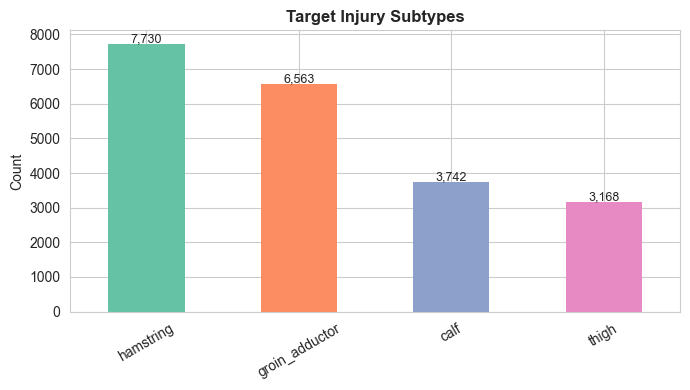


=== Label Category Distribution ===


,count,pct
label_category,,
keep,21203,100.0000



Target injuries: 21,203 episodes across 11,217 players
(hamstring, groin/adductor, calf, thigh — non-contact lower-limb soft-tissue)


In [7]:
# 4.1 Load pre-classified target injuries from NB01
# NB01 (01_football_datasets_exploration) classifies injuries using a curated
# regex pipeline into: hamstring, groin/adductor, calf, thigh (the "keep" set).
# This is narrower and more defensible than broad keyword matching.

target_injuries = pd.read_csv(TM_DIR / 'derived' / 'injury_label_table_keep.csv')
target_injuries['from_date'] = pd.to_datetime(target_injuries['from_date'], errors='coerce')
target_injuries['end_date'] = pd.to_datetime(target_injuries['end_date'], errors='coerce')

print("=== NB01 Target Injuries (injury_label_table_keep.csv) ===")
print(f"Total target injury spells: {len(target_injuries):,}")
print(f"Unique players:             {target_injuries['player_id'].nunique():,}")

print("\n=== Injury Subtype Distribution ===")
sub_counts = target_injuries['injury_subtype'].value_counts()
sub_pct = (sub_counts / len(target_injuries) * 100).round(1)
display(pd.DataFrame({'count': sub_counts, 'pct': sub_pct}))

fig, ax = plt.subplots(figsize=(7, 4))
sub_counts.plot.bar(ax=ax, color=sns.color_palette("Set2", len(sub_counts)), edgecolor='none')
ax.set_title('Target Injury Subtypes', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(sub_counts.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n=== Label Category Distribution ===")
cat_counts = target_injuries['label_category'].value_counts()
cat_pct = (cat_counts / len(target_injuries) * 100).round(1)
display(pd.DataFrame({'count': cat_counts, 'pct': cat_pct}))

# Mark on the raw injuries table which are target injuries (for reference)
injuries['injury_category'] = 'other'
target_mask = injuries['injury_reason'].isin(target_injuries['injury_reason'].unique())
injuries.loc[target_mask, 'injury_category'] = 'target'

print(f"\nTarget injuries: {len(target_injuries):,} episodes across {target_injuries['player_id'].nunique():,} players")
print("(hamstring, groin/adductor, calf, thigh — non-contact lower-limb soft-tissue)")

In [8]:
# 4.2 Target quality checks (using NB01 pre-classified data)
msk = target_injuries.copy()

print("=== Target Quality Checks (NB01 target injuries) ===")
print(f"\nDate precision:")
print(f"  from_date NaT: {msk['from_date'].isna().sum()} ({msk['from_date'].isna().mean()*100:.1f}%)")
print(f"  end_date NaT:  {msk['end_date'].isna().sum()} ({msk['end_date'].isna().mean()*100:.1f}%)")

print(f"\nDays missed distribution:")
display(msk['days_missed'].describe())

# Check for zero-day injuries (possibly not time-loss)
print(f"\nZero days missed: {(msk['days_missed'] == 0).sum()} ({(msk['days_missed'] == 0).mean()*100:.1f}%)")
print(f"1-3 days missed:  {((msk['days_missed'] >= 1) & (msk['days_missed'] <= 3)).sum()}")
print(f"4-7 days missed:  {((msk['days_missed'] >= 4) & (msk['days_missed'] <= 7)).sum()}")
print(f"8-28 days missed: {((msk['days_missed'] >= 8) & (msk['days_missed'] <= 28)).sum()}")
print(f"29+ days missed:  {(msk['days_missed'] >= 29).sum()}")

# Time-loss filter
is_time_loss_col = 'is_time_loss' in msk.columns
if is_time_loss_col:
    print(f"\nTime-loss injuries (is_time_loss=True): {msk['is_time_loss'].sum():,}")
    print(f"Non-time-loss: {(~msk['is_time_loss']).sum():,}")

# Check for overlapping injury episodes per player
msk_sorted = msk.dropna(subset=['from_date', 'end_date']).sort_values(['player_id', 'from_date'])
msk_sorted['prev_end'] = msk_sorted.groupby('player_id')['end_date'].shift(1)
overlaps = msk_sorted[msk_sorted['from_date'] < msk_sorted['prev_end']]
print(f"\nOverlapping injury episodes: {len(overlaps)} ({len(overlaps)/len(msk_sorted)*100:.1f}%)")

print(f"\n=== LEAKAGE RISK ASSESSMENT ===")
print("1. end_date / days_missed: These are POST-INJURY information.")
print("   We must ONLY use from_date to define when an injury occurred.")
print("   end_date and days_missed must NOT be used as features.")
print("2. The injury_reason text itself is post-diagnosis. We cannot use it")
print("   as a feature — only to define the target population.")
print("3. We must ensure no future injury information leaks into features at prediction time.")

=== Target Quality Checks (NB01 target injuries) ===

Date precision:
  from_date NaT: 0 (0.0%)
  end_date NaT:  191 (0.9%)

Days missed distribution:


count   21203.0000
mean       39.8483
std        71.3982
min         1.0000
25%        13.0000
50%        24.0000
75%        45.0000
max      4157.0000
Name: days_missed, dtype: float64


Zero days missed: 0 (0.0%)
1-3 days missed:  231
4-7 days missed:  1745
8-28 days missed: 10057
29+ days missed:  9170

Time-loss injuries (is_time_loss=True): 21,203
Non-time-loss: 0

Overlapping injury episodes: 77 (0.4%)

=== LEAKAGE RISK ASSESSMENT ===
1. end_date / days_missed: These are POST-INJURY information.
   We must ONLY use from_date to define when an injury occurred.
   end_date and days_missed must NOT be used as features.
2. The injury_reason text itself is post-diagnosis. We cannot use it
   as a feature — only to define the target population.
3. We must ensure no future injury information leaks into features at prediction time.


---
# 5. Preprocessing and Feature Engineering

## Strategy
1. Build a **player-day** panel from appearances data
2. Create rolling workload features (leakage-safe: only past information)
3. Create injury history features (leakage-safe: only past injuries)
4. Merge player demographics
5. Define the 14-day forward-looking target label

### Key leakage safeguards:
- All rolling features use **strictly past** windows (not including the current day)
- Target label looks **forward** 14 days from each row's date
- No future injury information enters features
- No end_date or days_missed used as features

In [9]:
# 5.1 Prepare appearances data
appearances['date'] = pd.to_datetime(appearances['date'], errors='coerce')
appearances = appearances.dropna(subset=['date', 'player_id', 'minutes_played'])
appearances['player_id'] = appearances['player_id'].astype(int)

# Focus on top-tier leagues to keep the population meaningful
# Merge with games to get competition info
games['date'] = pd.to_datetime(games['date'], errors='coerce')

# We keep all competitions for now — workload is workload regardless of competition
print(f"Appearances after cleaning: {appearances.shape}")
print(f"Date range: {appearances['date'].min()} to {appearances['date'].max()}")

# Filter to players who also appear in injury data (our modeling population)
core_player_ids = set(injuries['player_id'].unique()) & set(appearances['player_id'].unique())
app_core = appearances[appearances['player_id'].isin(core_player_ids)].copy()
print(f"\nCore population (have both injuries & appearances):")
print(f"  Players: {app_core['player_id'].nunique():,}")
print(f"  Appearance rows: {len(app_core):,}")
print(f"  Date range: {app_core['date'].min()} to {app_core['date'].max()}")

Appearances after cleaning: (1734466, 13)
Date range: 2012-07-03 00:00:00 to 2025-07-13 00:00:00

Core population (have both injuries & appearances):
  Players: 15,670
  Appearance rows: 1,418,820
  Date range: 2012-07-03 00:00:00 to 2025-07-13 00:00:00


In [10]:
# 5.2 Build player-day panel
# Instead of creating a row for every calendar day (which would be enormous),
# we create rows at match-day granularity and compute features from the match history.
# This is a defensible simplification: we predict risk on MATCH DAYS only,
# since that's when load-management decisions actually matter.

# For each player, sort appearances chronologically
app_core = app_core.sort_values(['player_id', 'date']).reset_index(drop=True)

# Add a season indicator based on the year of the match
# (European football season: Aug-May, so we use the year of August as the season start)
app_core['year'] = app_core['date'].dt.year
app_core['month'] = app_core['date'].dt.month
app_core['season'] = app_core.apply(
    lambda r: r['year'] if r['month'] >= 7 else r['year'] - 1, axis=1
)

print(f"Player-match panel: {app_core.shape}")
print(f"Season distribution:")
display(app_core['season'].value_counts().sort_index())

# Filter to seasons with reasonable coverage (2012+ based on appearances data)
app_core = app_core[app_core['season'] >= 2012].copy()
print(f"\nAfter filtering to 2012+ seasons: {app_core.shape}")
print(f"Players: {app_core['player_id'].nunique():,}")

Player-match panel: (1418820, 16)
Season distribution:


season
2012     91878
2013     95890
2014     96497
2015    103272
2016    106194
2017    106378
2018    109971
2019     97649
2020    132650
2021    117323
2022    124170
2023    121529
2024    115209
2025       210
Name: count, dtype: int64


After filtering to 2012+ seasons: (1418820, 16)
Players: 15,670


In [11]:
# 5.3 Rolling workload features (leakage-safe)
# All features use STRICTLY PAST information relative to each match date.

def compute_rolling_features(group):
    """Compute rolling workload features for a single player's match history."""
    group = group.sort_values('date').copy()
    dates = group['date'].values
    minutes = group['minutes_played'].values

    features = []
    for i in range(len(group)):
        current_date = dates[i]
        row = {}

        # Past matches within various windows
        for window_days in [7, 14, 28, 60, 90]:
            cutoff = current_date - np.timedelta64(window_days, 'D')
            mask = (dates[:i] > cutoff) & (dates[:i] <= current_date)
            past_minutes = minutes[:i][mask]
            past_dates = dates[:i][mask]

            row[f'matches_{window_days}d'] = len(past_minutes)
            row[f'minutes_{window_days}d'] = past_minutes.sum()
            row[f'avg_minutes_{window_days}d'] = past_minutes.mean() if len(past_minutes) > 0 else 0

        # Days since last match
        if i > 0:
            row['days_since_last_match'] = (current_date - dates[i-1]) / np.timedelta64(1, 'D')
        else:
            row['days_since_last_match'] = np.nan

        # Acute:Chronic workload ratio (7d / 28d average weekly)
        acute = row['minutes_7d']
        chronic_weekly = row['minutes_28d'] / 4.0 if row['matches_28d'] > 0 else 0
        row['acwr'] = acute / chronic_weekly if chronic_weekly > 0 else np.nan

        # Match congestion: matches in last 7 days
        row['congestion_7d'] = row['matches_7d']

        # Current match minutes (this is known at prediction time IF predicting post-match)
        row['current_minutes'] = minutes[i]

        # Was this a start or substitute? (proxy: >= 45 min = likely starter)
        row['likely_starter'] = int(minutes[i] >= 45)

        features.append(row)

    return pd.DataFrame(features, index=group.index)

print("Computing rolling workload features (this may take a few minutes)...")
workload_features = app_core.groupby('player_id', group_keys=False).apply(compute_rolling_features)
app_core = pd.concat([app_core, workload_features], axis=1)
print(f"Done. Shape: {app_core.shape}")
print(f"\nNew columns: {list(workload_features.columns)}")
display(app_core[['player_id', 'date', 'minutes_played', 'matches_7d', 'minutes_7d',
                   'matches_28d', 'minutes_28d', 'days_since_last_match', 'acwr']].head(15))

Computing rolling workload features (this may take a few minutes)...
Done. Shape: (1418820, 36)

New columns: ['matches_7d', 'minutes_7d', 'avg_minutes_7d', 'matches_14d', 'minutes_14d', 'avg_minutes_14d', 'matches_28d', 'minutes_28d', 'avg_minutes_28d', 'matches_60d', 'minutes_60d', 'avg_minutes_60d', 'matches_90d', 'minutes_90d', 'avg_minutes_90d', 'days_since_last_match', 'acwr', 'congestion_7d', 'current_minutes', 'likely_starter']


,player_id,date,minutes_played,matches_7d,minutes_7d,matches_28d,minutes_28d,days_since_last_match,acwr
0,10,2012-08-23,83,0,0,0,0,NaN,NaN
1,10,2012-08-26,90,1,83,1,83,3.0000,4.0000
2,10,2012-09-02,89,0,0,2,173,7.0000,0.0000
3,10,2012-09-16,90,0,0,3,262,14.0000,0.0000
4,10,2012-09-20,90,1,90,3,269,4.0000,1.3383
5,10,2012-09-23,14,1,90,3,269,3.0000,1.3383
6,10,2012-09-26,90,2,104,4,283,3.0000,1.4700
7,10,2012-09-30,90,1,90,4,284,4.0000,1.2676
8,10,2012-10-07,72,0,0,5,374,7.0000,0.0000
9,10,2012-10-20,90,0,0,4,266,13.0000,0.0000


In [12]:
# 5.4 Injury history features (leakage-safe)
# For each player-match row, compute injury history features using ONLY past injury dates.

# Use NB01 pre-classified target injuries (hamstring, groin, calf, thigh only)
inj_events = target_injuries[
    (target_injuries['from_date'].notna()) &
    (target_injuries['days_missed'] > 0)  # Only time-loss injuries
].copy()
inj_events = inj_events.sort_values(['player_id', 'from_date'])

print(f"Clean target time-loss injury events (from NB01): {len(inj_events):,}")
print(f"Unique players with such injuries: {inj_events['player_id'].nunique():,}")

def compute_injury_features(player_matches, player_injuries):
    """Compute injury history features for a player's match history."""
    if len(player_injuries) == 0:
        n = len(player_matches)
        return pd.DataFrame({
            'injuries_365d': np.zeros(n),
            'injuries_180d': np.zeros(n),
            'injuries_90d': np.zeros(n),
            'days_since_last_injury': np.full(n, np.nan),
            'career_injury_count': np.zeros(n),
            'recently_returned': np.zeros(n),  # returned from injury in last 28 days
        }, index=player_matches.index)

    inj_dates = player_injuries['from_date'].values
    inj_end_dates = player_injuries['end_date'].values
    match_dates = player_matches['date'].values

    results = []
    for i in range(len(player_matches)):
        current = match_dates[i]
        row = {}

        # Past injuries within windows
        past_inj = inj_dates[inj_dates < current]
        past_end = inj_end_dates[inj_dates < current]

        row['career_injury_count'] = len(past_inj)

        for window_days in [90, 180, 365]:
            cutoff = current - np.timedelta64(window_days, 'D')
            row[f'injuries_{window_days}d'] = int(np.sum(past_inj > cutoff))

        # Days since last injury onset
        if len(past_inj) > 0:
            row['days_since_last_injury'] = (current - past_inj[-1]) / np.timedelta64(1, 'D')
            # Recently returned: last injury ended within 28 days
            if len(past_end) > 0 and not pd.isna(past_end[-1]):
                days_since_return = (current - past_end[-1]) / np.timedelta64(1, 'D')
                row['recently_returned'] = int(0 <= days_since_return <= 28)
            else:
                row['recently_returned'] = 0
        else:
            row['days_since_last_injury'] = np.nan
            row['recently_returned'] = 0

        results.append(row)

    return pd.DataFrame(results, index=player_matches.index)

# Compute injury features for each player
print("Computing injury history features...")
injury_feat_parts = []
for pid, grp in app_core.groupby('player_id'):
    p_inj = inj_events[inj_events['player_id'] == pid]
    feat = compute_injury_features(grp, p_inj)
    injury_feat_parts.append(feat)

injury_features = pd.concat(injury_feat_parts)
app_core = pd.concat([app_core, injury_features], axis=1)

print(f"Done. Shape: {app_core.shape}")
display(app_core[['player_id', 'date', 'career_injury_count', 'injuries_365d',
                   'injuries_90d', 'days_since_last_injury', 'recently_returned']].head(15))

Clean target time-loss injury events (from NB01): 21,203
Unique players with such injuries: 11,217
Computing injury history features...
Done. Shape: (1418820, 42)


,player_id,date,career_injury_count,injuries_365d,injuries_90d,days_since_last_injury,recently_returned
0,10,2012-08-23,0.0000,0.0000,0.0000,NaN,0.0000
1,10,2012-08-26,0.0000,0.0000,0.0000,NaN,0.0000
2,10,2012-09-02,0.0000,0.0000,0.0000,NaN,0.0000
3,10,2012-09-16,0.0000,0.0000,0.0000,NaN,0.0000
4,10,2012-09-20,0.0000,0.0000,0.0000,NaN,0.0000
5,10,2012-09-23,0.0000,0.0000,0.0000,NaN,0.0000
6,10,2012-09-26,0.0000,0.0000,0.0000,NaN,0.0000
7,10,2012-09-30,0.0000,0.0000,0.0000,NaN,0.0000
8,10,2012-10-07,0.0000,0.0000,0.0000,NaN,0.0000
9,10,2012-10-20,0.0000,0.0000,0.0000,NaN,0.0000


In [13]:
# 5.5 Add player demographics
players['date_of_birth'] = pd.to_datetime(players['date_of_birth'], errors='coerce')

# Select relevant columns from players table
demo_cols = ['player_id', 'date_of_birth', 'position', 'sub_position', 'foot', 'height_in_cm']
player_demo = players[demo_cols].drop_duplicates(subset='player_id', keep='first').copy()

# Merge demographics
app_core = app_core.merge(player_demo, on='player_id', how='left')

# Compute age at match time
app_core['age'] = (app_core['date'] - app_core['date_of_birth']).dt.days / 365.25
app_core['age'] = app_core['age'].round(1)

# Encode position as broader category
app_core['position_group'] = app_core['position'].fillna('Unknown')

print(f"After demographics merge: {app_core.shape}")
print(f"\nAge stats:")
display(app_core['age'].describe())
print(f"\nPosition distribution:")
display(app_core['position_group'].value_counts())
print(f"\nFoot distribution:")
display(app_core['foot'].value_counts())
print(f"\nHeight stats:")
display(app_core['height_in_cm'].describe())

After demographics merge: (1418820, 49)

Age stats:


count   1418184.0000
mean         26.5571
std           4.1563
min          15.3000
25%          23.4000
50%          26.3000
75%          29.4000
max          43.7000
Name: age, dtype: float64


Position distribution:


position_group
Defender      476279
Midfield      439341
Attack        401713
Goalkeeper    100462
Missing         1021
Unknown            4
Name: count, dtype: int64


Foot distribution:


foot
right    1006707
left      348434
both       51526
Name: count, dtype: int64


Height stats:


count   1408903.0000
mean        182.2416
std           6.6091
min         158.0000
25%         178.0000
50%         183.0000
75%         187.0000
max         207.0000
Name: height_in_cm, dtype: float64

Computing 14-day injury target...

=== TARGET DISTRIBUTION ===


,count,pct
injury_14d,,
0,1404072,98.9610
1,14748,1.0390



Event prevalence: 0.0104 (1.04%)
Imbalance ratio: 1:96 (negative:positive)

=== TARGET BY SEASON ===


,events,total,prevalence,prevalence_pct
season,,,,
2012,516,91878,0.0056,0.5620
2013,714,95890,0.0074,0.7450
2014,796,96497,0.0082,0.8250
2015,910,103272,0.0088,0.8810
2016,925,106194,0.0087,0.8710
2017,954,106378,0.0090,0.8970
2018,1171,109971,0.0106,1.0650
2019,1288,97649,0.0132,1.3190
2020,1645,132650,0.0124,1.2400


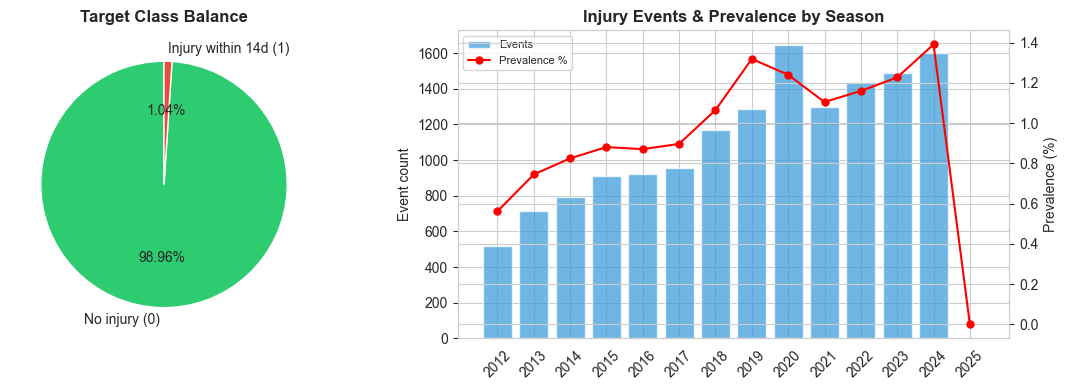

In [14]:
# 5.6 Define the TARGET: injury within next 14 days
# For each player-match row, check if the player has a musculoskeletal injury
# starting within the next 14 days (EXCLUSIVE of current date).

# Build a lookup: player_id -> sorted list of injury dates
inj_date_lookup = inj_events.groupby('player_id')['from_date'].apply(list).to_dict()

def label_injury_14d(row):
    """Check if player has an injury in the next 14 days."""
    pid = row['player_id']
    current = row['date']
    if pid not in inj_date_lookup:
        return 0
    for inj_date in inj_date_lookup[pid]:
        days_ahead = (inj_date - current).days
        if 1 <= days_ahead <= 14:
            return 1
        if days_ahead > 14:
            break  # sorted, so no more in window
    return 0

print("Computing 14-day injury target...")
app_core['injury_14d'] = app_core.apply(label_injury_14d, axis=1)

print(f"\n=== TARGET DISTRIBUTION ===")
target_counts = app_core['injury_14d'].value_counts()
target_pct = (target_counts / len(app_core) * 100).round(3)
display(pd.DataFrame({'count': target_counts, 'pct': target_pct}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Class balance pie
axes[0].pie(target_counts.values, labels=['No injury (0)', 'Injury within 14d (1)'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%', startangle=90,
            textprops={'fontsize': 10})
axes[0].set_title('Target Class Balance', fontsize=12, fontweight='bold')

prevalence = app_core['injury_14d'].mean()
print(f"\nEvent prevalence: {prevalence:.4f} ({prevalence*100:.2f}%)")
print(f"Imbalance ratio: 1:{int(1/prevalence)} (negative:positive)")

print(f"\n=== TARGET BY SEASON ===")
season_target = app_core.groupby('season')['injury_14d'].agg(['sum', 'count', 'mean'])
season_target.columns = ['events', 'total', 'prevalence']
season_target['prevalence_pct'] = (season_target['prevalence'] * 100).round(3)
display(season_target)

# Season prevalence trend
axes[1].bar(season_target.index.astype(str), season_target['events'], color='#3498db', alpha=0.7, label='Events')
ax2 = axes[1].twinx()
ax2.plot(season_target.index.astype(str), season_target['prevalence_pct'], 'ro-', markersize=5, label='Prevalence %')
axes[1].set_title('Injury Events & Prevalence by Season', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Event count')
ax2.set_ylabel('Prevalence (%)')
axes[1].tick_params(axis='x', rotation=45)
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.show()

=== FINAL MODELING DATASET ===
Shape: (1418820, 50)
Players: 15,670
Date range: 2012-07-03 00:00:00 to 2025-07-13 00:00:00

Feature summary statistics:


,count,mean,std,min,25%,50%,75%,max
matches_7d,1418820.0000,0.4397,0.5383,0.0000,0.0000,0.0000,1.0000,2.0000
minutes_7d,1418820.0000,31.4187,42.8915,0.0000,0.0000,0.0000,87.0000,225.0000
avg_minutes_7d,1418820.0000,29.8783,39.6917,0.0000,0.0000,0.0000,83.0000,135.0000
matches_14d,1418820.0000,1.2225,0.9085,0.0000,1.0000,1.0000,2.0000,4.0000
minutes_14d,1418820.0000,87.8984,75.1702,0.0000,8.0000,90.0000,148.0000,390.0000
avg_minutes_14d,1418820.0000,55.0570,37.9389,0.0000,7.5000,73.0000,90.0000,135.0000
matches_28d,1418820.0000,2.6064,1.5090,0.0000,2.0000,3.0000,4.0000,8.0000
minutes_28d,1418820.0000,187.5384,130.4704,0.0000,90.0000,180.0000,270.0000,780.0000
avg_minutes_28d,1418820.0000,63.0939,31.6420,0.0000,43.6667,77.0000,90.0000,135.0000
matches_60d,1418820.0000,5.4270,2.9929,0.0000,3.0000,6.0000,7.0000,17.0000



Missingness in features:


,missing,pct
days_since_last_injury,974928,68.7100
acwr,139390,9.8200
days_since_last_match,15670,1.1000
height_in_cm,9917,0.7000
age,636,0.0400


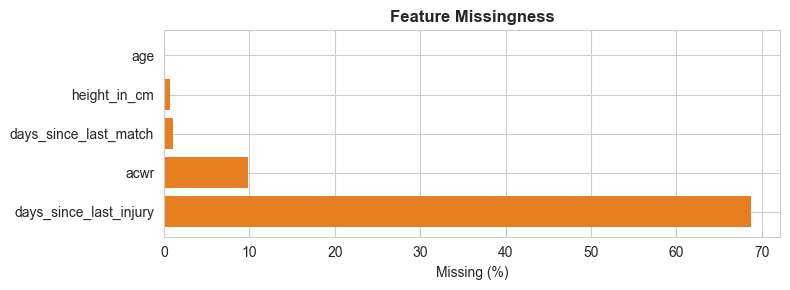


Correlation with target (top features):


injuries_365d            0.0671
career_injury_count      0.0626
injuries_180d            0.0572
injuries_90d             0.0464
days_since_last_injury   0.0457
recently_returned        0.0389
age                      0.0222
congestion_7d            0.0141
matches_7d               0.0141
minutes_7d               0.0137
matches_28d              0.0134
avg_minutes_7d           0.0129
matches_14d              0.0128
minutes_14d              0.0123
minutes_28d              0.0118
dtype: float64

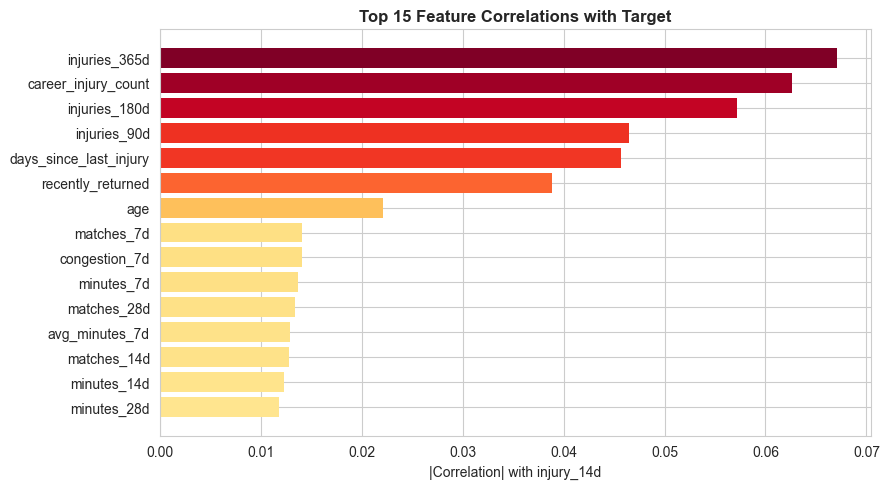

In [15]:
# 5.7 Final modeling dataset summary
FEATURE_COLS = [
    # Workload features
    'matches_7d', 'minutes_7d', 'avg_minutes_7d',
    'matches_14d', 'minutes_14d', 'avg_minutes_14d',
    'matches_28d', 'minutes_28d', 'avg_minutes_28d',
    'matches_60d', 'minutes_60d',
    'matches_90d', 'minutes_90d',
    'days_since_last_match', 'acwr', 'congestion_7d',
    'current_minutes', 'likely_starter',
    # Injury history
    'injuries_365d', 'injuries_180d', 'injuries_90d',
    'days_since_last_injury', 'career_injury_count', 'recently_returned',
    # Demographics
    'age', 'height_in_cm',
]

CATEGORICAL_COLS = ['position_group', 'foot']
TARGET_COL = 'injury_14d'

print("=== FINAL MODELING DATASET ===")
print(f"Shape: {app_core.shape}")
print(f"Players: {app_core['player_id'].nunique():,}")
print(f"Date range: {app_core['date'].min()} to {app_core['date'].max()}")
print(f"\nFeature summary statistics:")
display(app_core[FEATURE_COLS].describe().T)

print(f"\nMissingness in features:")
feat_miss = app_core[FEATURE_COLS].isnull().sum()
feat_miss_pct = (feat_miss / len(app_core) * 100).round(2)
miss_df = pd.DataFrame({'missing': feat_miss, 'pct': feat_miss_pct}).query('missing > 0').sort_values('pct', ascending=False)
display(miss_df)

if len(miss_df) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3, len(miss_df) * 0.4)))
    ax.barh(miss_df.index, miss_df['pct'], color='#e67e22', edgecolor='none')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Feature Missingness', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f"\nCorrelation with target (top features):")
numeric_feats = app_core[FEATURE_COLS].copy()
correlations = numeric_feats.corrwith(app_core[TARGET_COL]).abs().sort_values(ascending=False)
display(correlations.head(15))

fig, ax = plt.subplots(figsize=(9, 5))
top_corr = correlations.head(15).sort_values()
colors = plt.cm.YlOrRd(top_corr.values / top_corr.max())
ax.barh(top_corr.index, top_corr.values, color=colors, edgecolor='none')
ax.set_xlabel('|Correlation| with injury_14d')
ax.set_title('Top 15 Feature Correlations with Target', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 6. Temporal Validation Design

**Critical:** No random splits. We use strict chronological splitting.

- **Train:** Seasons 2012–2018 (learn patterns from historical data)
- **Validation:** Season 2019 (tune hyperparameters, select threshold)
- **Test:** Seasons 2020–2024 (final unbiased evaluation)

This mimics a real deployment scenario: the model is trained on past data and evaluated on future seasons it has never seen.

We also report prevalence in each split to check for drift.

In [16]:
# 6.1 Temporal split
from sklearn.preprocessing import LabelEncoder

# Prepare modeling dataframe: drop rows with too much missing data
model_df = app_core.copy()

# Encode categoricals
le_pos = LabelEncoder()
model_df['position_enc'] = le_pos.fit_transform(model_df['position_group'].fillna('Unknown'))
le_foot = LabelEncoder()
model_df['foot_enc'] = le_foot.fit_transform(model_df['foot'].fillna('Unknown'))

ALL_FEATURE_COLS = FEATURE_COLS + ['position_enc', 'foot_enc']

# Fill NaN in features with sensible defaults
# days_since_last_match: fill with median (player's first appearance)
# days_since_last_injury: fill with large value (no prior injury)
# acwr: fill with 1.0 (balanced)
# height_in_cm: fill with median
fill_values = {
    'days_since_last_match': model_df['days_since_last_match'].median(),
    'days_since_last_injury': 9999,  # no prior injury
    'acwr': 1.0,
    'height_in_cm': model_df['height_in_cm'].median(),
    'age': model_df['age'].median(),
}
model_df[ALL_FEATURE_COLS] = model_df[ALL_FEATURE_COLS].fillna(fill_values)
# Fill any remaining NaN with 0
model_df[ALL_FEATURE_COLS] = model_df[ALL_FEATURE_COLS].fillna(0)

# Temporal split
train = model_df[model_df['season'] <= 2018]
val = model_df[model_df['season'] == 2019]
test = model_df[model_df['season'] >= 2020]

print("=== TEMPORAL SPLIT ===")
for name, split in [('Train (≤2018)', train), ('Val (2019)', val), ('Test (≥2020)', test)]:
    n = len(split)
    events = split[TARGET_COL].sum()
    prev = split[TARGET_COL].mean()
    players = split['player_id'].nunique()
    print(f"\n{name}:")
    print(f"  Rows: {n:,}  |  Players: {players:,}  |  Events: {int(events):,}  |  Prevalence: {prev:.4f} ({prev*100:.2f}%)")
    print(f"  Date range: {split['date'].min().date()} to {split['date'].max().date()}")
    print(f"  Seasons: {sorted(split['season'].unique())}")

X_train = train[ALL_FEATURE_COLS].values
y_train = train[TARGET_COL].values
X_val = val[ALL_FEATURE_COLS].values
y_val = val[TARGET_COL].values
X_test = test[ALL_FEATURE_COLS].values
y_test = test[TARGET_COL].values

print(f"\nFeature matrix shapes: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")

=== TEMPORAL SPLIT ===

Train (≤2018):
  Rows: 710,080  |  Players: 10,360  |  Events: 5,986  |  Prevalence: 0.0084 (0.84%)
  Date range: 2012-07-03 to 2019-06-01
  Seasons: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]

Val (2019):
  Rows: 97,649  |  Players: 5,399  |  Events: 1,288  |  Prevalence: 0.0132 (1.32%)
  Date range: 2019-07-06 to 2020-06-30
  Seasons: [np.int64(2019)]

Test (≥2020):
  Rows: 611,091  |  Players: 10,357  |  Events: 7,474  |  Prevalence: 0.0122 (1.22%)
  Date range: 2020-07-01 to 2025-07-13
  Seasons: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Feature matrix shapes: train=(710080, 28), val=(97649, 28), test=(611091, 28)


---
# 7. Baselines

Before any ML model, we establish simple baselines to understand what "beating random" actually means in this problem.

1. **Prevalence baseline**: predict base rate for everyone
2. **Always-negative**: predict 0 for everyone (strong baseline when prevalence < 5%)
3. **Recent-injury heuristic**: flag players who had an injury in last 90 days
4. **Workload heuristic**: flag players with high recent match load

In [17]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    brier_score_loss, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, log_loss
)

def evaluate_model(y_true, y_prob, y_pred=None, name="Model"):
    """Comprehensive evaluation for a rare-event binary classifier."""
    results = {'name': name}

    # Discrimination
    try:
        results['roc_auc'] = roc_auc_score(y_true, y_prob)
    except:
        results['roc_auc'] = np.nan
    results['pr_auc'] = average_precision_score(y_true, y_prob)

    # Calibration
    results['brier'] = brier_score_loss(y_true, y_prob)
    try:
        results['log_loss'] = log_loss(y_true, y_prob)
    except:
        results['log_loss'] = np.nan

    # Base rate comparison
    results['prevalence'] = y_true.mean()
    results['mean_predicted'] = y_prob.mean()

    return results

def evaluate_at_threshold(y_true, y_prob, threshold, name="Model"):
    """Evaluate at a specific decision threshold."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    n = len(y_true)

    return {
        'name': name,
        'threshold': threshold,
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'f1': f1_score(y_true, y_pred),
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'flagged': (tp + fp),
        'flagged_pct': (tp + fp) / n * 100,
        'alerts_per_week': (tp + fp) / n * 25 * 7,  # ~25 players, daily check, scale to week
    }

# --- Baseline 1: Prevalence baseline ---
train_prev = y_train.mean()
val_prev_pred = np.full(len(y_val), train_prev)
test_prev_pred = np.full(len(y_test), train_prev)

# --- Baseline 2: Always negative ---
val_neg_pred = np.zeros(len(y_val))
test_neg_pred = np.zeros(len(y_test))

# --- Baseline 3: Recent injury heuristic ---
val_recent_inj = val['injuries_90d'].values
val_recent_inj_prob = np.clip(val_recent_inj / val_recent_inj.max(), 0, 1) if val_recent_inj.max() > 0 else val_recent_inj
test_recent_inj = test['injuries_90d'].values
test_recent_inj_prob = np.clip(test_recent_inj / test_recent_inj.max(), 0, 1) if test_recent_inj.max() > 0 else test_recent_inj

# --- Baseline 4: High workload heuristic ---
val_workload = val['minutes_7d'].values
val_workload_prob = np.clip(val_workload / val_workload.max(), 0, 1) if val_workload.max() > 0 else val_workload
test_workload = test['minutes_7d'].values
test_workload_prob = np.clip(test_workload / test_workload.max(), 0, 1) if test_workload.max() > 0 else test_workload

# Evaluate all baselines on validation set
baseline_results = []
for name, probs in [
    ('Prevalence', val_prev_pred),
    ('Recent Injury (90d)', val_recent_inj_prob),
    ('Workload (min 7d)', val_workload_prob),
]:
    try:
        r = evaluate_model(y_val, probs, name=name)
        baseline_results.append(r)
    except Exception as e:
        print(f"  {name}: evaluation failed — {e}")

print("=== BASELINE RESULTS (Validation Set) ===")
baseline_df = pd.DataFrame(baseline_results)
display(baseline_df[['name', 'roc_auc', 'pr_auc', 'brier', 'prevalence', 'mean_predicted']].round(4))

print(f"\n** Key insight: PR-AUC for a random classifier = prevalence = {y_val.mean():.4f} **")
print("Any useful model must have PR-AUC meaningfully above this.")

=== BASELINE RESULTS (Validation Set) ===


,name,roc_auc,pr_auc,brier,prevalence,mean_predicted
0,Prevalence,0.5000,0.0132,0.0130,0.0132,0.0084
1,Recent Injury (90d),0.5509,0.0184,0.0167,0.0132,0.0127
2,Workload (min 7d),0.5276,0.0138,0.0763,0.0132,0.1544



** Key insight: PR-AUC for a random classifier = prevalence = 0.0132 **
Any useful model must have PR-AUC meaningfully above this.


---
# 8. Models

We train three models, from simple to complex:

1. **Penalised Logistic Regression** — interpretable baseline, handles imbalance via class weights
2. **Random Forest** — moderate complexity, handles non-linearities
3. **LightGBM** — strongest nonlinear model, well-suited for tabular rare-event problems

All models use class weighting to address imbalance. We do NOT use SMOTE or oversampling — these create synthetic positives that can mislead calibration.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# --- Model 1: Penalised Logistic Regression ---
print("=== Model 1: Penalised Logistic Regression ===")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    class_weight='balanced',
    C=0.1,  # regularisation
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr.fit(X_train_scaled, y_train)

lr_val_prob = lr.predict_proba(X_val_scaled)[:, 1]
lr_test_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Coefficients
lr_coefs = pd.DataFrame({
    'feature': ALL_FEATURE_COLS,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)
print("\nLogistic Regression coefficients:")
display(lr_coefs)

lr_val_result = evaluate_model(y_val, lr_val_prob, name='LR (val)')
print(f"\nValidation: ROC-AUC={lr_val_result['roc_auc']:.4f}, PR-AUC={lr_val_result['pr_auc']:.4f}, Brier={lr_val_result['brier']:.4f}")

=== Model 1: Penalised Logistic Regression ===

Logistic Regression coefficients:


,feature,coefficient
10,minutes_60d,0.2240
17,likely_starter,0.2109
24,age,0.1881
18,injuries_365d,0.1093
11,matches_90d,0.1042
4,minutes_14d,0.1030
22,career_injury_count,0.0820
23,recently_returned,0.0640
8,avg_minutes_28d,0.0610
6,matches_28d,0.0456



Validation: ROC-AUC=0.6796, PR-AUC=0.0351, Brier=0.2467


In [19]:
# --- Model 2: Random Forest ---
print("=== Model 2: Random Forest ===")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_val_prob = rf.predict_proba(X_val)[:, 1]
rf_test_prob = rf.predict_proba(X_test)[:, 1]

# Feature importance
rf_importance = pd.DataFrame({
    'feature': ALL_FEATURE_COLS,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nRandom Forest feature importances:")
display(rf_importance)

rf_val_result = evaluate_model(y_val, rf_val_prob, name='RF (val)')
print(f"\nValidation: ROC-AUC={rf_val_result['roc_auc']:.4f}, PR-AUC={rf_val_result['pr_auc']:.4f}, Brier={rf_val_result['brier']:.4f}")

=== Model 2: Random Forest ===

Random Forest feature importances:


,feature,importance
21,days_since_last_injury,0.2201
22,career_injury_count,0.1612
18,injuries_365d,0.0979
24,age,0.0913
19,injuries_180d,0.0510
16,current_minutes,0.0472
25,height_in_cm,0.0332
12,minutes_90d,0.0307
10,minutes_60d,0.0291
7,minutes_28d,0.0272



Validation: ROC-AUC=0.6873, PR-AUC=0.0375, Brier=0.2162


In [20]:
# --- Model 3: LightGBM ---
print("=== Model 3: LightGBM ===")
try:
    import lightgbm as lgb

    # Compute scale_pos_weight for imbalance
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    scale_pos = neg_count / pos_count if pos_count > 0 else 1

    lgb_model = lgb.LGBMClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=100,
        scale_pos_weight=scale_pos,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1,
        n_jobs=-1,
    )

    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )

    lgb_val_prob = lgb_model.predict_proba(X_val)[:, 1]
    lgb_test_prob = lgb_model.predict_proba(X_test)[:, 1]

    lgb_importance = pd.DataFrame({
        'feature': ALL_FEATURE_COLS,
        'importance': lgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    print("\nLightGBM feature importances:")
    display(lgb_importance)

    lgb_val_result = evaluate_model(y_val, lgb_val_prob, name='LightGBM (val)')
    print(f"\nValidation: ROC-AUC={lgb_val_result['roc_auc']:.4f}, PR-AUC={lgb_val_result['pr_auc']:.4f}, Brier={lgb_val_result['brier']:.4f}")

    HAS_LGB = True

except ImportError:
    print("LightGBM not installed. Falling back to XGBoost or skipping.")
    try:
        from xgboost import XGBClassifier
        lgb_model = XGBClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            scale_pos_weight=scale_pos, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=1.0, reg_lambda=1.0, random_state=42,
            eval_metric='logloss', use_label_encoder=False
        )
        lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        lgb_val_prob = lgb_model.predict_proba(X_val)[:, 1]
        lgb_test_prob = lgb_model.predict_proba(X_test)[:, 1]
        lgb_val_result = evaluate_model(y_val, lgb_val_prob, name='XGBoost (val)')
        print(f"Validation: ROC-AUC={lgb_val_result['roc_auc']:.4f}, PR-AUC={lgb_val_result['pr_auc']:.4f}")
        HAS_LGB = True
    except ImportError:
        print("Neither LightGBM nor XGBoost available. Using RF as best model.")
        lgb_val_prob = rf_val_prob
        lgb_test_prob = rf_test_prob
        lgb_val_result = rf_val_result
        HAS_LGB = False

=== Model 3: LightGBM ===

LightGBM feature importances:


,feature,importance
24,age,7
16,current_minutes,6
8,avg_minutes_28d,3
25,height_in_cm,3
13,days_since_last_match,2
5,avg_minutes_14d,2
22,career_injury_count,2
20,injuries_90d,1
12,minutes_90d,1
18,injuries_365d,1



Validation: ROC-AUC=0.6689, PR-AUC=0.0277, Brier=0.0467


=== ALL MODELS COMPARISON (Validation Set) ===



,name,roc_auc,pr_auc,brier,prevalence,mean_predicted
0,Prevalence Baseline,0.5000,0.0132,0.0130,0.0132,0.0084
1,Recent Injury (90d),0.5509,0.0184,0.0167,0.0132,0.0127
2,Workload (min 7d),0.5276,0.0138,0.0763,0.0132,0.1544
3,Logistic Regression,0.6796,0.0351,0.2467,0.0132,0.4780
4,Random Forest,0.6873,0.0375,0.2162,0.0132,0.4495
5,LightGBM/XGBoost,0.6689,0.0277,0.0467,0.0132,0.1545


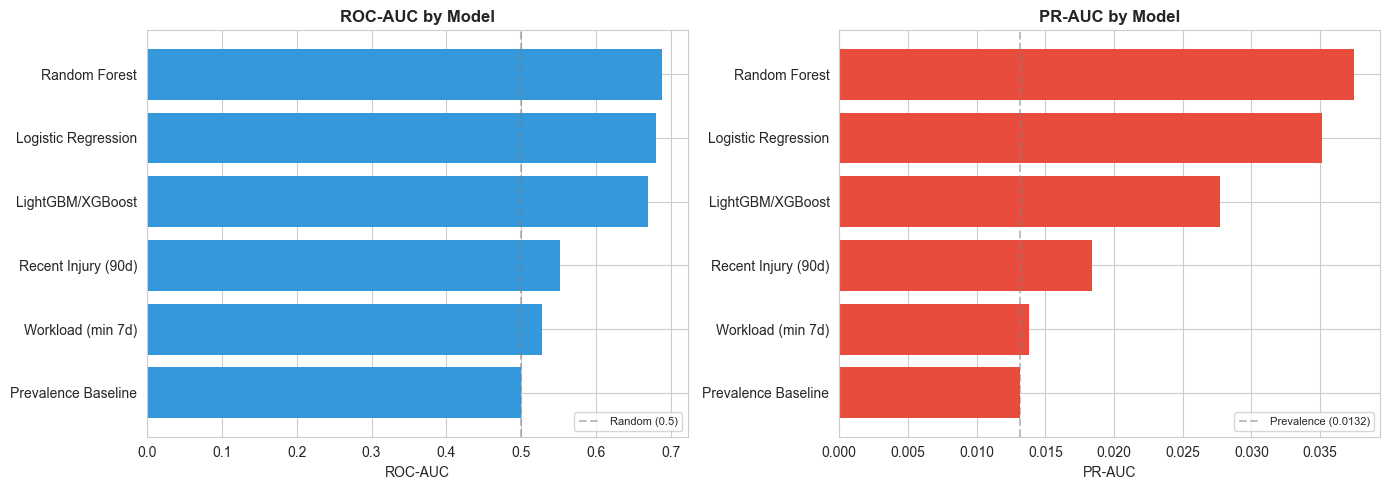


Random classifier PR-AUC = 0.0132
Models must meaningfully exceed this to claim any discrimination ability.


In [21]:
# --- Model Comparison Summary ---
print("=== ALL MODELS COMPARISON (Validation Set) ===\n")

all_results = []
model_probs_val = {}
model_probs_test = {}

for name, val_prob, test_prob in [
    ('Prevalence Baseline', val_prev_pred, test_prev_pred),
    ('Recent Injury (90d)', val_recent_inj_prob, test_recent_inj_prob),
    ('Workload (min 7d)', val_workload_prob, test_workload_prob),
    ('Logistic Regression', lr_val_prob, lr_test_prob),
    ('Random Forest', rf_val_prob, rf_test_prob),
    ('LightGBM/XGBoost', lgb_val_prob, lgb_test_prob),
]:
    r = evaluate_model(y_val, val_prob, name=name)
    all_results.append(r)
    model_probs_val[name] = val_prob
    model_probs_test[name] = test_prob

comparison_df = pd.DataFrame(all_results)
display(comparison_df[['name', 'roc_auc', 'pr_auc', 'brier', 'prevalence', 'mean_predicted']].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = comparison_df.sort_values('pr_auc', ascending=True)

# ROC-AUC
axes[0].barh(plot_df['name'], plot_df['roc_auc'], color='#3498db', edgecolor='none')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0].set_xlabel('ROC-AUC')
axes[0].set_title('ROC-AUC by Model', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8)

# PR-AUC
axes[1].barh(plot_df['name'], plot_df['pr_auc'], color='#e74c3c', edgecolor='none')
axes[1].axvline(x=y_val.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Prevalence ({y_val.mean():.4f})')
axes[1].set_xlabel('PR-AUC')
axes[1].set_title('PR-AUC by Model', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nRandom classifier PR-AUC = {y_val.mean():.4f}")
print("Models must meaningfully exceed this to claim any discrimination ability.")

---
# 9. Evaluation Focused on Rare-Event Utility

This is the critical section. We evaluate the **best model** (by validation PR-AUC) on the **test set** with metrics that matter operationally:

- PR-AUC (primary metric)
- Precision at various alert budgets
- Recall at fixed precision levels
- Confusion matrices at business-justified thresholds
- Expected alert volumes

In [22]:
# 9.1 Select best model and evaluate on TEST set
# Pick best model by validation PR-AUC
best_name = comparison_df.loc[comparison_df['pr_auc'].idxmax(), 'name']
best_val_prob = model_probs_val[best_name]
best_test_prob = model_probs_test[best_name]

print(f"=== BEST MODEL: {best_name} ===")
print(f"Selected by validation PR-AUC\n")

# Test set evaluation
test_result = evaluate_model(y_test, best_test_prob, name=f'{best_name} (test)')
print("TEST SET METRICS:")
for k, v in test_result.items():
    if k != 'name':
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# Also evaluate all models on test
print(f"\n=== ALL MODELS ON TEST SET ===")
test_results = []
for name, test_prob in model_probs_test.items():
    r = evaluate_model(y_test, test_prob, name=name)
    test_results.append(r)

test_comparison = pd.DataFrame(test_results)
display(test_comparison[['name', 'roc_auc', 'pr_auc', 'brier', 'prevalence', 'mean_predicted']].round(4))

=== BEST MODEL: Random Forest ===
Selected by validation PR-AUC

TEST SET METRICS:
  roc_auc: 0.6686
  pr_auc: 0.0254
  brier: 0.2309
  log_loss: 0.6558
  prevalence: 0.0122
  mean_predicted: 0.4650

=== ALL MODELS ON TEST SET ===


,name,roc_auc,pr_auc,brier,prevalence,mean_predicted
0,Prevalence Baseline,0.5000,0.0122,0.0121,0.0122,0.0084
1,Recent Injury (90d),0.5420,0.0157,0.0134,0.0122,0.0083
2,Workload (min 7d),0.5407,0.0137,0.0705,0.0122,0.1499
3,Logistic Regression,0.6605,0.0268,0.2744,0.0122,0.5046
4,Random Forest,0.6686,0.0254,0.2309,0.0122,0.4650
5,LightGBM/XGBoost,0.6554,0.0226,0.0528,0.0122,0.1719


=== THRESHOLD ANALYSIS — Random Forest on TEST SET ===

Each row = one threshold. Key columns: precision, recall, alerts/week, flagged %


,threshold,precision,recall,specificity,f1,tp,fp,flagged,flagged_pct,alerts_per_week
0,0.0100,0.0122,1.0000,0.0000,0.0242,7474,603617,611091,100.0000,175.0000
1,0.0200,0.0122,1.0000,0.0000,0.0242,7474,603617,611091,100.0000,175.0000
2,0.0300,0.0122,1.0000,0.0000,0.0242,7474,603617,611091,100.0000,175.0000
3,0.0500,0.0122,1.0000,0.0000,0.0242,7474,603617,611091,100.0000,175.0000
4,0.0800,0.0122,1.0000,0.0000,0.0242,7474,603617,611091,100.0000,175.0000
5,0.1000,0.0122,1.0000,0.0000,0.0242,7474,603617,611091,100.0000,175.0000
6,0.1500,0.0122,1.0000,0.0000,0.0242,7474,603617,611091,100.0000,175.0000
7,0.2000,0.0122,1.0000,0.0000,0.0242,7474,603617,611091,100.0000,175.0000
8,0.3000,0.0126,0.9876,0.0412,0.0249,7381,578723,586104,95.9111,167.8444
9,0.4319,0.0178,0.7289,0.5028,0.0348,5448,300098,305546,50.0001,87.5001


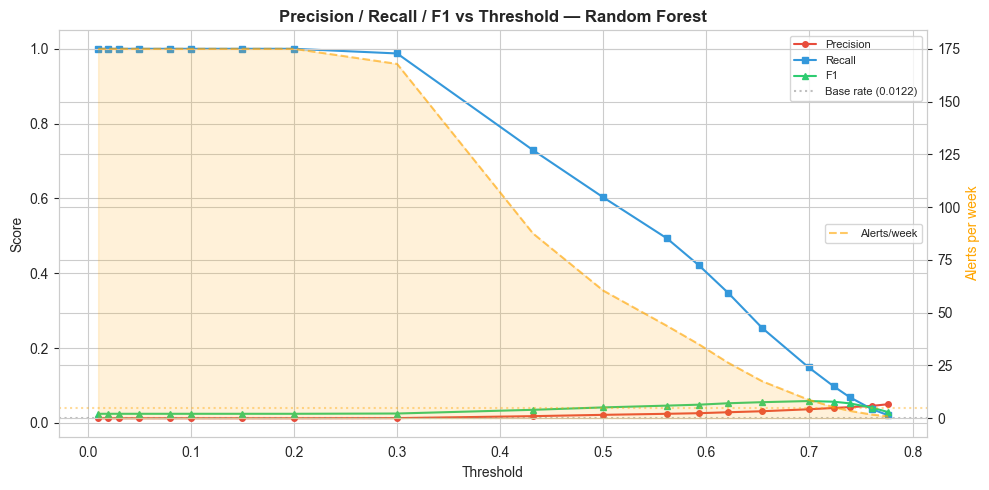


=== OPERATIONAL INTERPRETATION ===
A medical staff can handle ~3-5 alerts per week.
Look for rows where alerts_per_week is in that range.
Then check: is precision meaningfully above the base rate?
Base rate (test): 0.0122 (1.22%)

If precision at tolerable alert volume ≈ base rate, the model adds NO value.


In [23]:
# 9.2 Threshold analysis — the operationally critical part
# We evaluate the best model at various thresholds, focusing on
# what alert volume is produced and whether precision is acceptable.

print(f"=== THRESHOLD ANALYSIS — {best_name} on TEST SET ===\n")

# Find a range of meaningful thresholds
percentiles = [99.5, 99, 98, 97, 95, 90, 85, 80, 75, 50]
thresholds_from_percentiles = np.percentile(best_test_prob, percentiles)

# Also add some absolute thresholds
candidate_thresholds = sorted(set(
    list(thresholds_from_percentiles) +
    [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.50]
))

threshold_results = []
for t in candidate_thresholds:
    r = evaluate_at_threshold(y_test, best_test_prob, t, name=best_name)
    threshold_results.append(r)

threshold_df = pd.DataFrame(threshold_results)
# Only show thresholds where at least 1 alert is generated
threshold_df = threshold_df[threshold_df['flagged'] > 0]

print("Each row = one threshold. Key columns: precision, recall, alerts/week, flagged %")
display(threshold_df[['threshold', 'precision', 'recall', 'specificity', 'f1',
                       'tp', 'fp', 'flagged', 'flagged_pct', 'alerts_per_week']].round(4))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(threshold_df['threshold'], threshold_df['precision'], 'o-', color='#e74c3c', label='Precision', markersize=4)
ax1.plot(threshold_df['threshold'], threshold_df['recall'], 's-', color='#3498db', label='Recall', markersize=4)
ax1.plot(threshold_df['threshold'], threshold_df['f1'], '^-', color='#2ecc71', label='F1', markersize=4)
ax1.axhline(y=y_test.mean(), color='gray', linestyle=':', alpha=0.5, label=f'Base rate ({y_test.mean():.4f})')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title(f'Precision / Recall / F1 vs Threshold — {best_name}', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')
ax2 = ax1.twinx()
ax2.fill_between(threshold_df['threshold'], threshold_df['alerts_per_week'], alpha=0.15, color='orange')
ax2.plot(threshold_df['threshold'], threshold_df['alerts_per_week'], '--', color='orange', alpha=0.6, label='Alerts/week')
ax2.set_ylabel('Alerts per week', color='orange')
ax2.axhline(y=5, color='orange', linestyle=':', alpha=0.4)
ax2.legend(fontsize=8, loc='center right')
plt.tight_layout()
plt.show()

print("\n=== OPERATIONAL INTERPRETATION ===")
print("A medical staff can handle ~3-5 alerts per week.")
print("Look for rows where alerts_per_week is in that range.")
print("Then check: is precision meaningfully above the base rate?")
print(f"Base rate (test): {y_test.mean():.4f} ({y_test.mean()*100:.2f}%)")
print("\nIf precision at tolerable alert volume ≈ base rate, the model adds NO value.")

---
# 10. Calibration and Threshold Analysis

We check whether the predicted probabilities are trustworthy before using them for any risk communication.

=== CALIBRATION ANALYSIS ===

Risk Decile Analysis — Random Forest (Test Set)
'lift' = observed rate / base rate. Lift > 1 in top deciles = some discrimination.



,decile,count,observed_rate,predicted_mean,predicted_min,predicted_max,lift
0,0,61110,0.0047,0.2998,0.2005,0.3275,0.3853
1,1,61109,0.0060,0.3410,0.3275,0.3531,0.4870
2,2,61109,0.0069,0.3647,0.3531,0.3768,0.5619
3,3,61109,0.0074,0.3901,0.3768,0.4037,0.6048
4,4,61109,0.0082,0.4174,0.4037,0.4319,0.6717
5,5,61109,0.0094,0.4501,0.4319,0.4714,0.7707
6,6,61109,0.0125,0.4981,0.4714,0.5276,1.0222
7,7,61109,0.0157,0.5611,0.5276,0.5928,1.2871
8,8,61109,0.0205,0.6220,0.5928,0.6543,1.6765
9,9,61109,0.0310,0.7059,0.6543,0.8455,2.5328


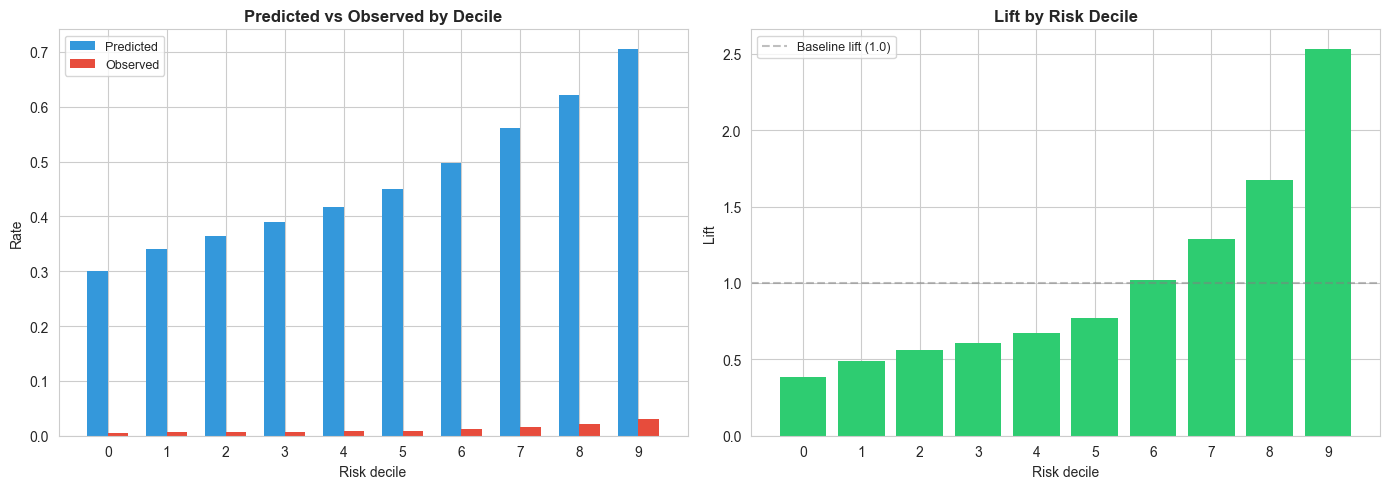


Brier score (test): 0.230865
Brier score of prevalence baseline: 0.012081
Brier Skill Score: -18.1098
  (BSS > 0 means better than prevalence baseline; BSS near 0 = no skill)


In [24]:
# 10.1 Calibration analysis
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

print("=== CALIBRATION ANALYSIS ===\n")

# Risk decile analysis: group predictions into deciles, compare observed vs predicted
def risk_decile_analysis(y_true, y_prob, n_bins=10, name="Model"):
    """Bin predictions into quantile groups and compare observed vs predicted."""
    df = pd.DataFrame({'y_true': y_true, 'y_prob': y_prob})
    # Use qcut with duplicates='drop' for potentially concentrated predictions
    try:
        df['decile'] = pd.qcut(df['y_prob'], n_bins, labels=False, duplicates='drop')
    except:
        df['decile'] = pd.cut(df['y_prob'], n_bins, labels=False)

    summary = df.groupby('decile').agg(
        count=('y_true', 'count'),
        observed_rate=('y_true', 'mean'),
        predicted_mean=('y_prob', 'mean'),
        predicted_min=('y_prob', 'min'),
        predicted_max=('y_prob', 'max'),
    ).reset_index()
    summary['lift'] = summary['observed_rate'] / y_true.mean()
    return summary

# Calibration for best model
decile_df = risk_decile_analysis(y_test, best_test_prob, n_bins=10, name=best_name)
print(f"Risk Decile Analysis — {best_name} (Test Set)")
print("'lift' = observed rate / base rate. Lift > 1 in top deciles = some discrimination.\n")
display(decile_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Observed vs predicted by decile
x = range(len(decile_df))
w = 0.35
axes[0].bar([i - w/2 for i in x], decile_df['predicted_mean'], w, label='Predicted', color='#3498db', edgecolor='none')
axes[0].bar([i + w/2 for i in x], decile_df['observed_rate'], w, label='Observed', color='#e74c3c', edgecolor='none')
axes[0].set_xlabel('Risk decile')
axes[0].set_ylabel('Rate')
axes[0].set_title('Predicted vs Observed by Decile', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].legend(fontsize=9)

# Lift chart
axes[1].bar(x, decile_df['lift'], color='#2ecc71', edgecolor='none')
axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Baseline lift (1.0)')
axes[1].set_xlabel('Risk decile')
axes[1].set_ylabel('Lift')
axes[1].set_title('Lift by Risk Decile', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

# Brier score decomposition
print(f"\nBrier score (test): {brier_score_loss(y_test, best_test_prob):.6f}")
print(f"Brier score of prevalence baseline: {brier_score_loss(y_test, np.full(len(y_test), y_test.mean())):.6f}")
brier_skill = 1 - brier_score_loss(y_test, best_test_prob) / brier_score_loss(y_test, np.full(len(y_test), y_test.mean()))
print(f"Brier Skill Score: {brier_skill:.4f}")
print("  (BSS > 0 means better than prevalence baseline; BSS near 0 = no skill)")

In [25]:
# 10.2 Platt scaling (post-hoc calibration) on validation set, evaluate on test
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression as LR_Platt

print("=== PLATT SCALING (Post-hoc calibration) ===\n")

# Fit Platt scaling on validation predictions
platt = LR_Platt()
platt.fit(best_val_prob.reshape(-1, 1), y_val)

# Calibrate test predictions
best_test_prob_calibrated = platt.predict_proba(best_test_prob.reshape(-1, 1))[:, 1]

print(f"Before calibration:")
print(f"  Mean predicted (test): {best_test_prob.mean():.6f}")
print(f"  Observed rate (test):  {y_test.mean():.6f}")
print(f"  Brier: {brier_score_loss(y_test, best_test_prob):.6f}")

print(f"\nAfter Platt scaling:")
print(f"  Mean predicted (test): {best_test_prob_calibrated.mean():.6f}")
print(f"  Observed rate (test):  {y_test.mean():.6f}")
print(f"  Brier: {brier_score_loss(y_test, best_test_prob_calibrated):.6f}")

# Compare calibration
cal_result = evaluate_model(y_test, best_test_prob_calibrated, name=f'{best_name} (calibrated)')
print(f"\nCalibrated model: ROC-AUC={cal_result['roc_auc']:.4f}, PR-AUC={cal_result['pr_auc']:.4f}")

# Risk decile after calibration
decile_cal = risk_decile_analysis(y_test, best_test_prob_calibrated, n_bins=10)
print(f"\nCalibrated Risk Deciles:")
display(decile_cal.round(4))

=== PLATT SCALING (Post-hoc calibration) ===

Before calibration:
  Mean predicted (test): 0.465021
  Observed rate (test):  0.012231
  Brier: 0.230865

After Platt scaling:
  Mean predicted (test): 0.014182
  Observed rate (test):  0.012231
  Brier: 0.012023

Calibrated model: ROC-AUC=0.6686, PR-AUC=0.0254

Calibrated Risk Deciles:


,decile,count,observed_rate,predicted_mean,predicted_min,predicted_max,lift
0,0,61110,0.0047,0.0051,0.0031,0.0059,0.3853
1,1,61109,0.0060,0.0063,0.0059,0.0067,0.4870
2,2,61109,0.0069,0.0071,0.0067,0.0075,0.5619
3,3,61109,0.0074,0.0080,0.0075,0.0085,0.6048
4,4,61109,0.0082,0.0092,0.0085,0.0098,0.6717
5,5,61109,0.0094,0.0108,0.0098,0.0119,0.7707
6,6,61109,0.0125,0.0137,0.0119,0.0157,1.0222
7,7,61109,0.0157,0.0186,0.0157,0.0217,1.2871
8,8,61109,0.0205,0.0251,0.0217,0.0292,1.6765
9,9,61109,0.0310,0.0381,0.0292,0.0725,2.5328


In [26]:
# 10.3 Bootstrap confidence intervals for key metrics
print("=== BOOTSTRAP CONFIDENCE INTERVALS (Test Set) ===\n")

np.random.seed(42)
n_boot = 500
boot_roc = []
boot_pr = []
boot_brier = []

for _ in range(n_boot):
    idx = np.random.choice(len(y_test), size=len(y_test), replace=True)
    y_b = y_test[idx]
    p_b = best_test_prob[idx]
    if y_b.sum() == 0 or y_b.sum() == len(y_b):
        continue
    boot_roc.append(roc_auc_score(y_b, p_b))
    boot_pr.append(average_precision_score(y_b, p_b))
    boot_brier.append(brier_score_loss(y_b, p_b))

boot_roc = np.array(boot_roc)
boot_pr = np.array(boot_pr)
boot_brier = np.array(boot_brier)

print(f"ROC-AUC:  {np.mean(boot_roc):.4f} [{np.percentile(boot_roc, 2.5):.4f}, {np.percentile(boot_roc, 97.5):.4f}]")
print(f"PR-AUC:   {np.mean(boot_pr):.4f} [{np.percentile(boot_pr, 2.5):.4f}, {np.percentile(boot_pr, 97.5):.4f}]")
print(f"Brier:    {np.mean(boot_brier):.6f} [{np.percentile(boot_brier, 2.5):.6f}, {np.percentile(boot_brier, 97.5):.6f}]")
print(f"\nPrevalence (test): {y_test.mean():.4f}")
print(f"If the PR-AUC CI overlaps with the prevalence, the model has no reliable discrimination.")

=== BOOTSTRAP CONFIDENCE INTERVALS (Test Set) ===

ROC-AUC:  0.6690 [0.6631, 0.6756]
PR-AUC:   0.0255 [0.0243, 0.0267]
Brier:    0.230856 [0.230533, 0.231171]

Prevalence (test): 0.0122
If the PR-AUC CI overlaps with the prevalence, the model has no reliable discrimination.


---
# 11. Error Analysis

We investigate where the model fails and whether it has meaningful subgroup variation.

=== SUBGROUP PERFORMANCE ANALYSIS (Test Set) ===


--- By Position ---


,subgroup,n,events,prevalence,roc_auc,pr_auc,brier
0,Attack,177154,2390,0.0135,0.6721,0.0275,0.2351
1,Defender,205827,2785,0.0135,0.6512,0.0263,0.2382
2,Goalkeeper,41232,232,0.0056,0.6738,0.0121,0.1822
3,Midfield,186650,2064,0.0111,0.6717,0.0242,0.2294


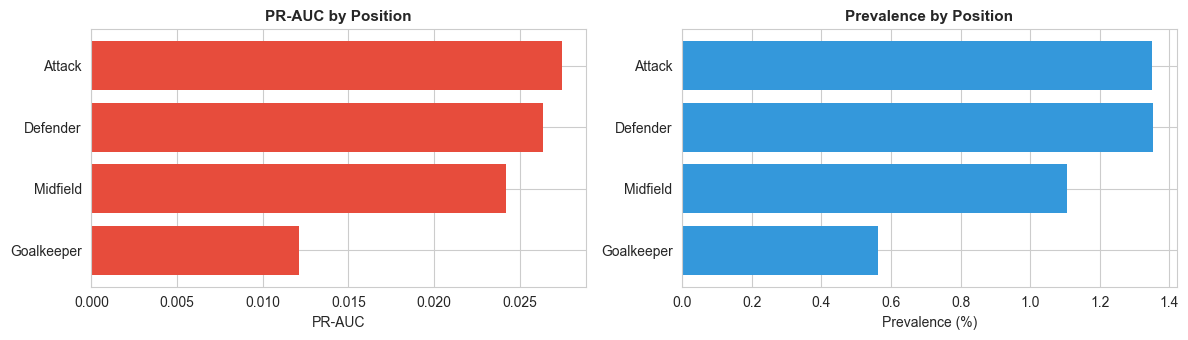


--- By Age Band ---


,subgroup,n,events,prevalence,roc_auc,pr_auc,brier
0,<22,83531,787,0.0094,0.6667,0.0214,0.1554
1,22-26,200440,2245,0.0112,0.6553,0.0218,0.2045
2,26-30,184427,2505,0.0136,0.6691,0.0280,0.2522
3,30-34,109234,1485,0.0136,0.6811,0.0285,0.2865
4,34+,33459,452,0.0135,0.6959,0.0291,0.2780


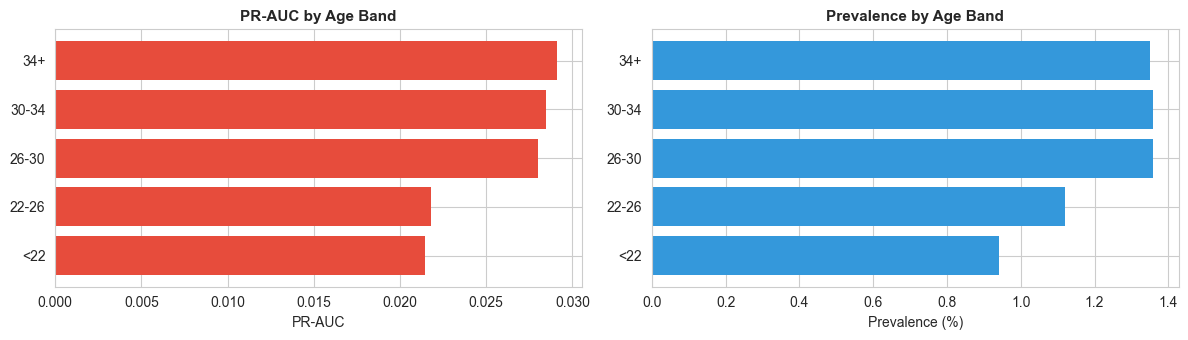


--- By Prior Injury ---


,subgroup,n,events,prevalence,roc_auc,pr_auc,brier
0,Has prior injury,249726,4832,0.0193,0.6198,0.0306,0.3481
1,No prior injury,361365,2642,0.0073,0.5752,0.0097,0.1498


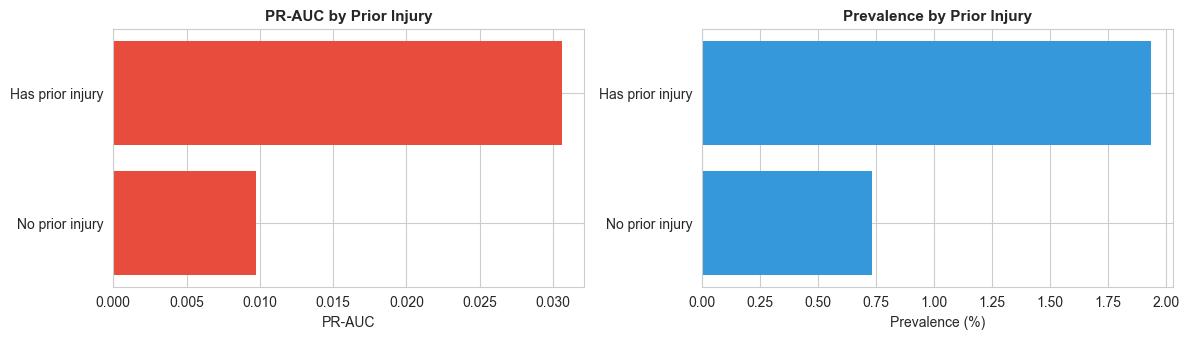


--- By Recent Return ---


,subgroup,n,events,prevalence,roc_auc,pr_auc,brier
0,Not recently returned,598514,6957,0.0116,0.6587,0.0229,0.2255
1,Recently returned,12577,517,0.0411,0.5298,0.0458,0.4861


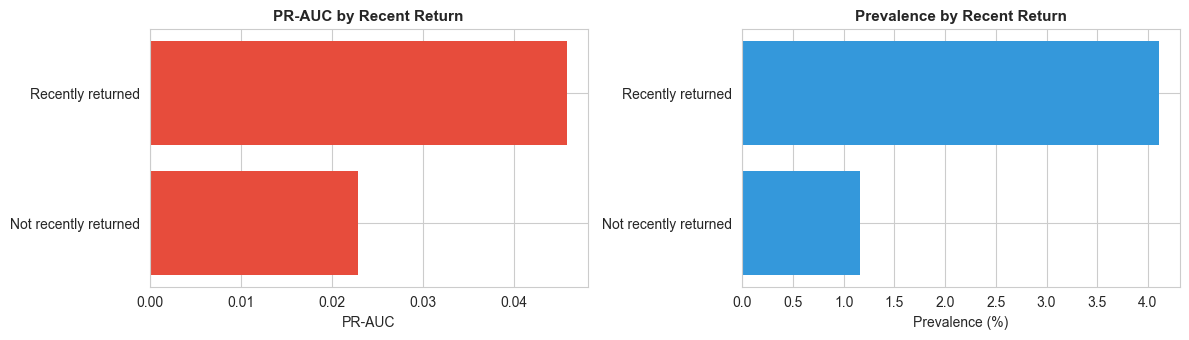


--- By Workload Group ---


,subgroup,n,events,prevalence,roc_auc,pr_auc,brier
0,Low load,204117,1984,0.0097,0.6722,0.0219,0.1999
1,Medium load,204211,2534,0.0124,0.6695,0.0270,0.2459
2,High load,202763,2956,0.0146,0.6511,0.0270,0.2469


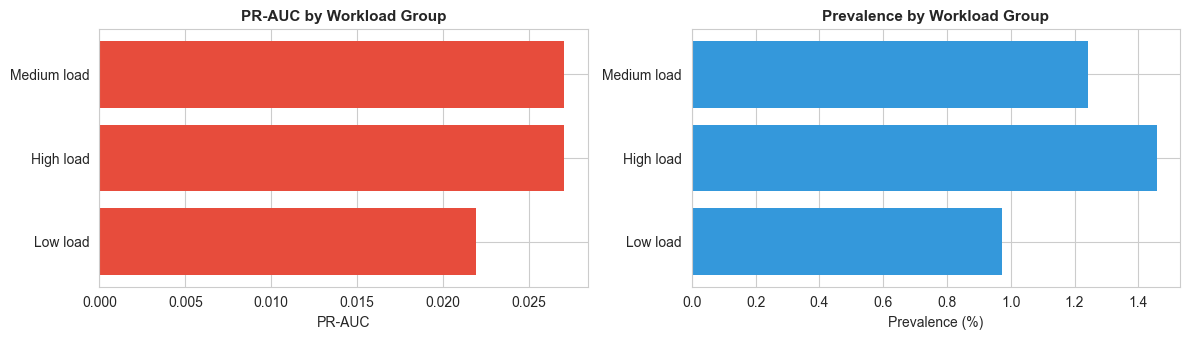


--- By Season ---


,subgroup,n,events,prevalence,roc_auc,pr_auc,brier
0,2020,132650,1645,0.0124,0.6789,0.0287,0.2240
1,2021,117323,1296,0.0110,0.6490,0.0235,0.2296
2,2022,124170,1440,0.0116,0.6606,0.0225,0.2275
3,2023,121529,1491,0.0123,0.6928,0.0289,0.2325
4,2024,115209,1602,0.0139,0.6560,0.0253,0.2418


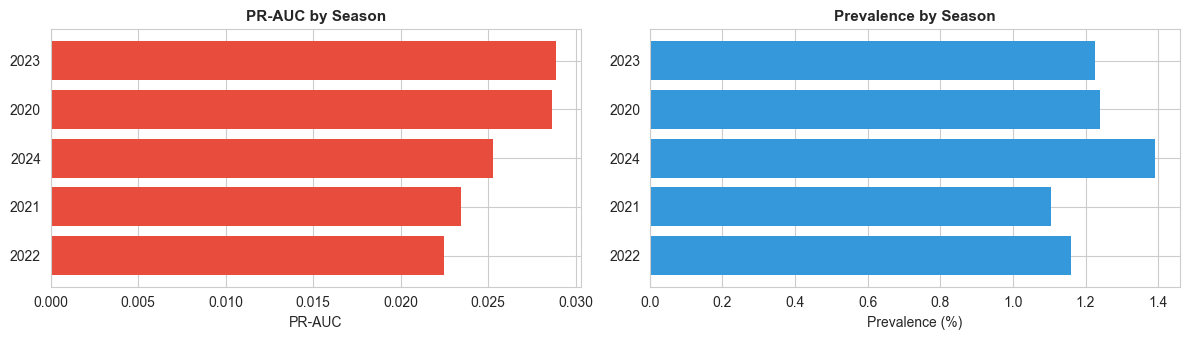

In [27]:
# 11.1 Subgroup performance analysis
test_df = test.copy()
test_df['pred_prob'] = best_test_prob

# Create subgroups for analysis
test_df['age_band'] = pd.cut(test_df['age'], bins=[15, 22, 26, 30, 34, 45], labels=['<22', '22-26', '26-30', '30-34', '34+'])
test_df['prior_injury'] = (test_df['career_injury_count'] > 0).map({True: 'Has prior injury', False: 'No prior injury'})
test_df['recent_return'] = test_df['recently_returned'].map({1: 'Recently returned', 0: 'Not recently returned'})
test_df['workload_group'] = pd.qcut(test_df['minutes_28d'], q=3, labels=['Low load', 'Medium load', 'High load'], duplicates='drop')

def subgroup_performance(df, group_col, y_col='injury_14d', prob_col='pred_prob'):
    """Evaluate model performance by subgroup."""
    results = []
    for name, grp in df.groupby(group_col, observed=True):
        if grp[y_col].sum() < 5:  # Skip groups with < 5 events
            continue
        try:
            r = {
                'subgroup': name,
                'n': len(grp),
                'events': int(grp[y_col].sum()),
                'prevalence': grp[y_col].mean(),
                'roc_auc': roc_auc_score(grp[y_col], grp[prob_col]),
                'pr_auc': average_precision_score(grp[y_col], grp[prob_col]),
                'brier': brier_score_loss(grp[y_col], grp[prob_col]),
            }
            results.append(r)
        except:
            pass
    return pd.DataFrame(results)

print("=== SUBGROUP PERFORMANCE ANALYSIS (Test Set) ===\n")

subgroup_configs = [
    ('Position', 'position_group'),
    ('Age Band', 'age_band'),
    ('Prior Injury', 'prior_injury'),
    ('Recent Return', 'recent_return'),
    ('Workload Group', 'workload_group'),
    ('Season', 'season'),
]

for group_name, group_col in subgroup_configs:
    print(f"\n--- By {group_name} ---")
    sg = subgroup_performance(test_df, group_col)
    if len(sg) > 0:
        display(sg.round(4))
        fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
        sg_sorted = sg.sort_values('pr_auc', ascending=True)
        axes[0].barh(sg_sorted['subgroup'].astype(str), sg_sorted['pr_auc'], color='#e74c3c', edgecolor='none')
        axes[0].set_xlabel('PR-AUC')
        axes[0].set_title(f'PR-AUC by {group_name}', fontsize=11, fontweight='bold')
        axes[1].barh(sg_sorted['subgroup'].astype(str), sg_sorted['prevalence'] * 100, color='#3498db', edgecolor='none')
        axes[1].set_xlabel('Prevalence (%)')
        axes[1].set_title(f'Prevalence by {group_name}', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("  Insufficient data for subgroup analysis.")

=== ERROR ANALYSIS at threshold=0.7604 ===

True Positives: 276
False Positives: 5835
False Negatives: 7198


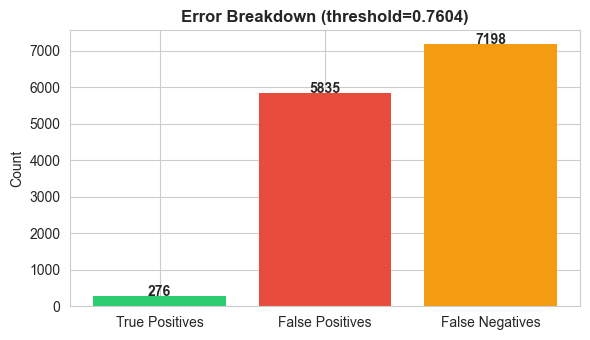


Feature comparison across error types:


,True Positive (mean),False Positive (mean),False Negative (mean),Unflagged Neg (mean)
age,29.2700,29.1400,27.2500,26.7800
minutes_28d,207.7600,187.5900,207.5700,183.3900
matches_28d,2.8100,2.5100,2.9700,2.6800
days_since_last_match,9.9900,11.3800,15.6400,18.8800
career_injury_count,3.3300,3.1800,1.5000,0.7900
injuries_365d,1.7100,1.5200,0.4300,0.1600
acwr,0.9800,1.1500,0.8000,0.7600
recently_returned,0.4500,0.4400,0.0500,0.0200


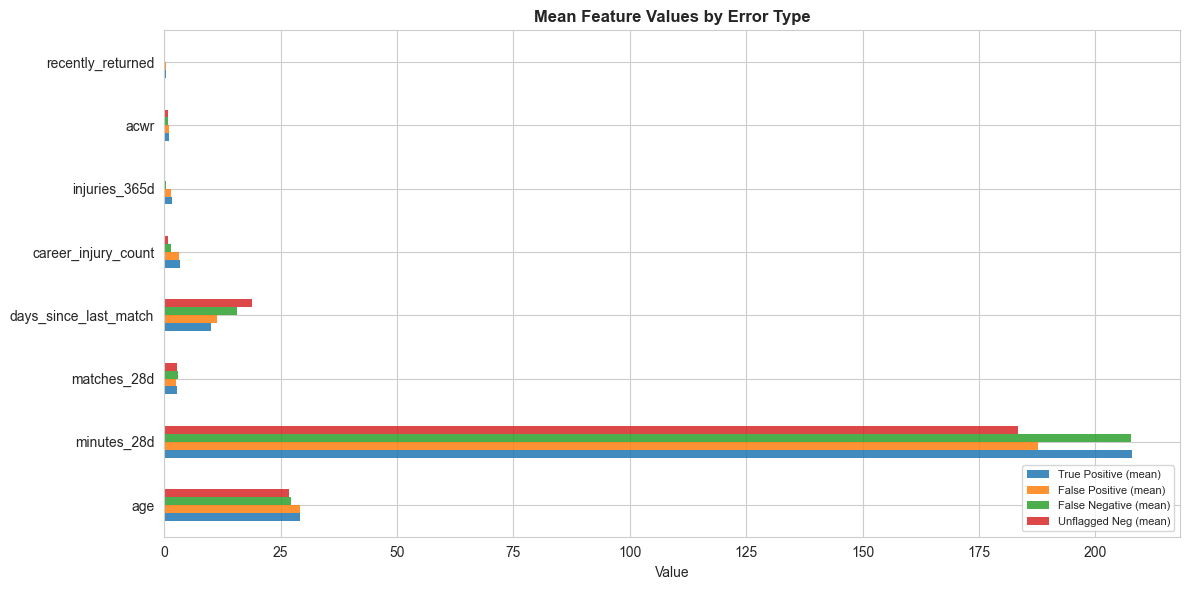


=== KEY QUESTION: Is the model flagging 'exposure' or 'risk'? ===
If FP and TP have similar feature profiles, the model may simply be
flagging high-activity players, not genuinely higher-risk ones.
Compare the TP and FP columns — if they look similar, the model
is likely capturing workload volume, not injury-specific risk.


In [28]:
# 11.2 False positive / false negative analysis
# At a reasonable threshold, inspect what types of cases are being flagged
# Use the median-ish threshold from the threshold analysis

# Pick a threshold that gives ~1-5% flagged
candidate_t = threshold_df[threshold_df['flagged_pct'].between(0.5, 5.0)]
if len(candidate_t) > 0:
    chosen_threshold = candidate_t.iloc[len(candidate_t)//2]['threshold']
else:
    chosen_threshold = np.percentile(best_test_prob, 97)

test_df['pred_flag'] = (test_df['pred_prob'] >= chosen_threshold).astype(int)

print(f"=== ERROR ANALYSIS at threshold={chosen_threshold:.4f} ===\n")

tp_mask = (test_df['pred_flag'] == 1) & (test_df['injury_14d'] == 1)
fp_mask = (test_df['pred_flag'] == 1) & (test_df['injury_14d'] == 0)
fn_mask = (test_df['pred_flag'] == 0) & (test_df['injury_14d'] == 1)

print(f"True Positives: {tp_mask.sum()}")
print(f"False Positives: {fp_mask.sum()}")
print(f"False Negatives: {fn_mask.sum()}")

# Confusion breakdown bar
fig, ax = plt.subplots(figsize=(6, 3.5))
counts = [tp_mask.sum(), fp_mask.sum(), fn_mask.sum()]
labels = ['True Positives', 'False Positives', 'False Negatives']
colors = ['#2ecc71', '#e74c3c', '#f39c12']
bars = ax.bar(labels, counts, color=colors, edgecolor='none')
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, str(v), ha='center', fontsize=10, fontweight='bold')
ax.set_title(f'Error Breakdown (threshold={chosen_threshold:.4f})', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Compare feature distributions: FP vs TP vs unflagged
if fp_mask.sum() > 0 and tp_mask.sum() > 0:
    analysis_cols = ['age', 'minutes_28d', 'matches_28d', 'days_since_last_match',
                     'career_injury_count', 'injuries_365d', 'acwr', 'recently_returned']
    comparison = pd.DataFrame({
        'True Positive (mean)': test_df.loc[tp_mask, analysis_cols].mean(),
        'False Positive (mean)': test_df.loc[fp_mask, analysis_cols].mean(),
        'False Negative (mean)': test_df.loc[fn_mask, analysis_cols].mean(),
        'Unflagged Neg (mean)': test_df.loc[~test_df['pred_flag'].astype(bool) & ~test_df['injury_14d'].astype(bool), analysis_cols].mean(),
    })
    print(f"\nFeature comparison across error types:")
    display(comparison.round(2))

    fig, ax = plt.subplots(figsize=(12, 6))
    comparison.plot.barh(ax=ax, edgecolor='none', alpha=0.85)
    ax.set_title('Mean Feature Values by Error Type', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.show()

    print(f"\n=== KEY QUESTION: Is the model flagging 'exposure' or 'risk'? ===")
    print("If FP and TP have similar feature profiles, the model may simply be")
    print("flagging high-activity players, not genuinely higher-risk ones.")
    print("Compare the TP and FP columns — if they look similar, the model")
    print("is likely capturing workload volume, not injury-specific risk.")

---
# 12. Visualizations

All plots support decision-making. No decorative charts.

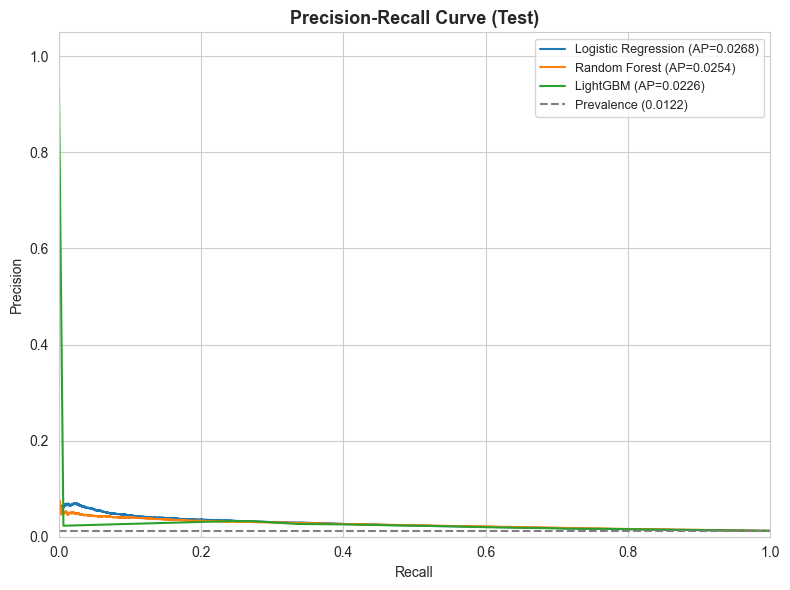

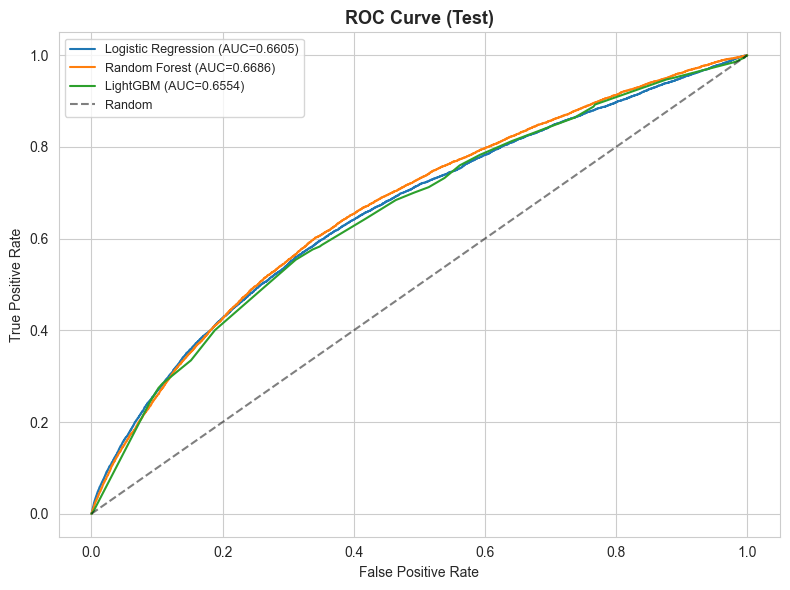

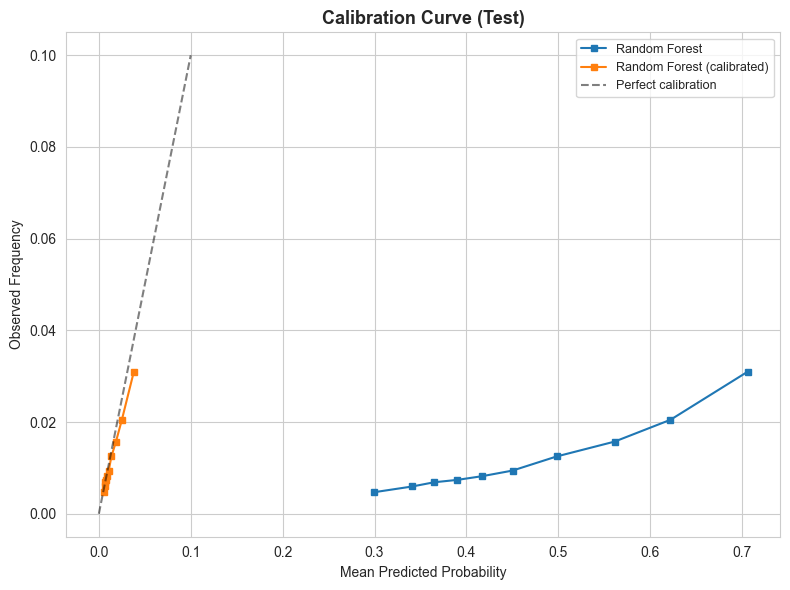

In [ ]:
# 12.1 PR Curve, ROC Curve, Calibration Curve (separate figures)

model_probs = [('Random Forest', rf_test_prob), ('Logistic Regression', lr_test_prob), ('LightGBM', lgb_test_prob)]

# ── Precision-Recall Curve ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for name, prob in model_probs:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.4f})')
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'Prevalence ({y_test.mean():.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Test)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, max(0.05, ax.get_ylim()[1])])
plt.tight_layout()
plt.savefig('../notebooks/fig_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ROC Curve ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for name, prob in model_probs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (Test)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../notebooks/fig_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Calibration Curve ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for name, prob in [(best_name, best_test_prob), (f'{best_name} (calibrated)', best_test_prob_calibrated)]:
    try:
        fraction_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy='quantile')
        ax.plot(mean_pred, fraction_pos, 's-', label=name, markersize=5)
    except:
        pass
ax.plot([0, 0.1], [0, 0.1], 'k--', alpha=0.5, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curve (Test)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../notebooks/fig_calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

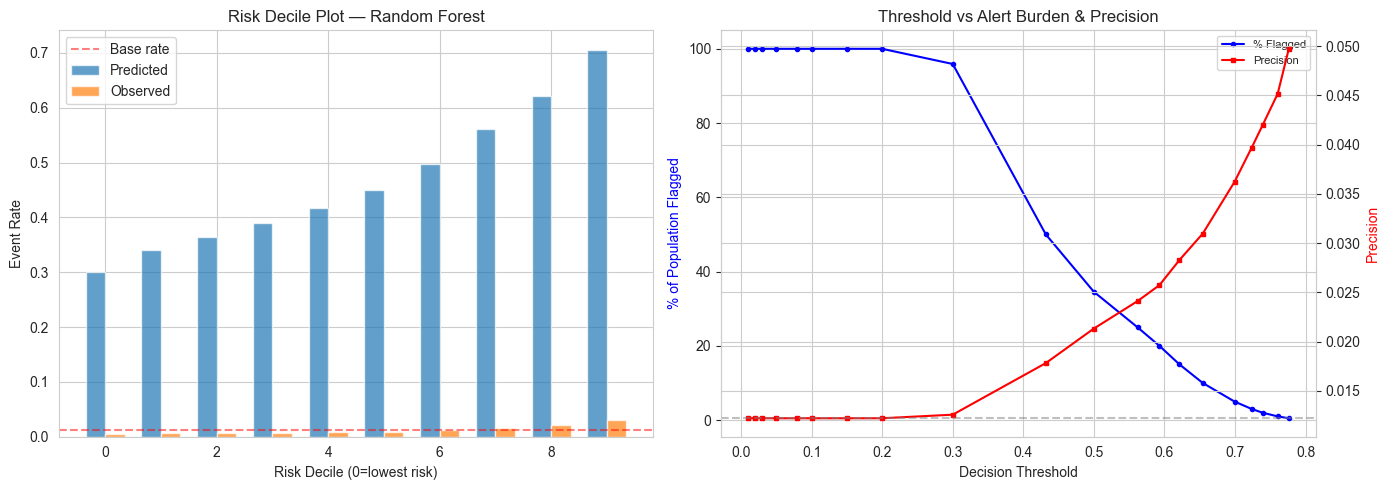

In [30]:
# 12.2 Risk decile plot and threshold-alert tradeoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Risk Decile Plot ---
ax = axes[0]
decile_plot = risk_decile_analysis(y_test, best_test_prob, n_bins=10)
x_pos = range(len(decile_plot))
width = 0.35
ax.bar([p - width/2 for p in x_pos], decile_plot['predicted_mean'], width, label='Predicted', alpha=0.7)
ax.bar([p + width/2 for p in x_pos], decile_plot['observed_rate'], width, label='Observed', alpha=0.7)
ax.axhline(y=y_test.mean(), color='red', linestyle='--', alpha=0.5, label='Base rate')
ax.set_xlabel('Risk Decile (0=lowest risk)')
ax.set_ylabel('Event Rate')
ax.set_title(f'Risk Decile Plot — {best_name}')
ax.legend()

# --- Threshold vs Alert Burden ---
ax = axes[1]
valid_thresh = threshold_df[threshold_df['flagged'] > 0].copy()
ax.plot(valid_thresh['threshold'], valid_thresh['flagged_pct'], 'b-o', markersize=3, label='% Flagged')
ax2 = ax.twinx()
ax2.plot(valid_thresh['threshold'], valid_thresh['precision'], 'r-s', markersize=3, label='Precision')
ax2.axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('% of Population Flagged', color='blue')
ax2.set_ylabel('Precision', color='red')
ax.set_title('Threshold vs Alert Burden & Precision')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig('../notebooks/fig_decile_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

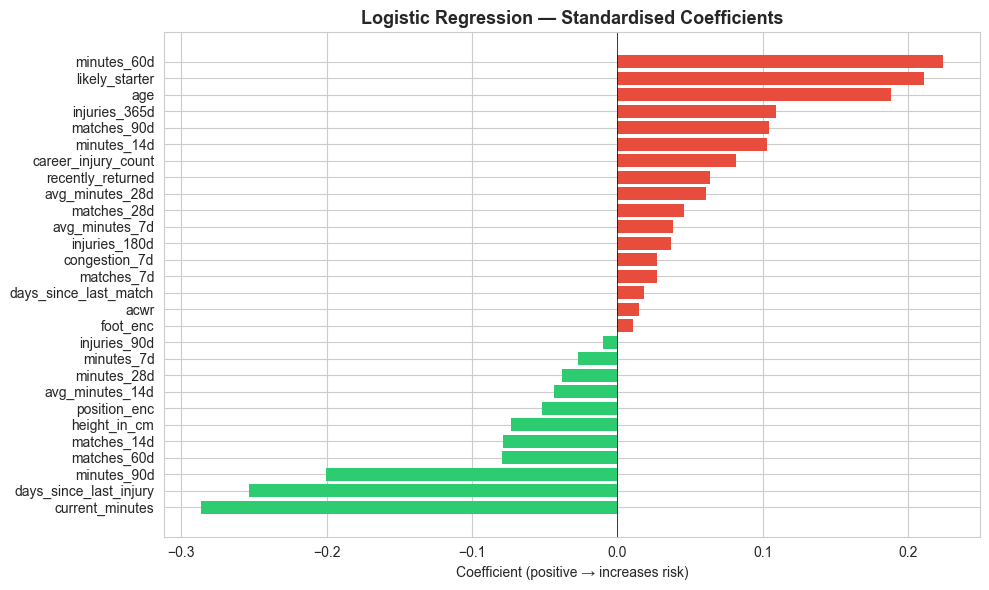

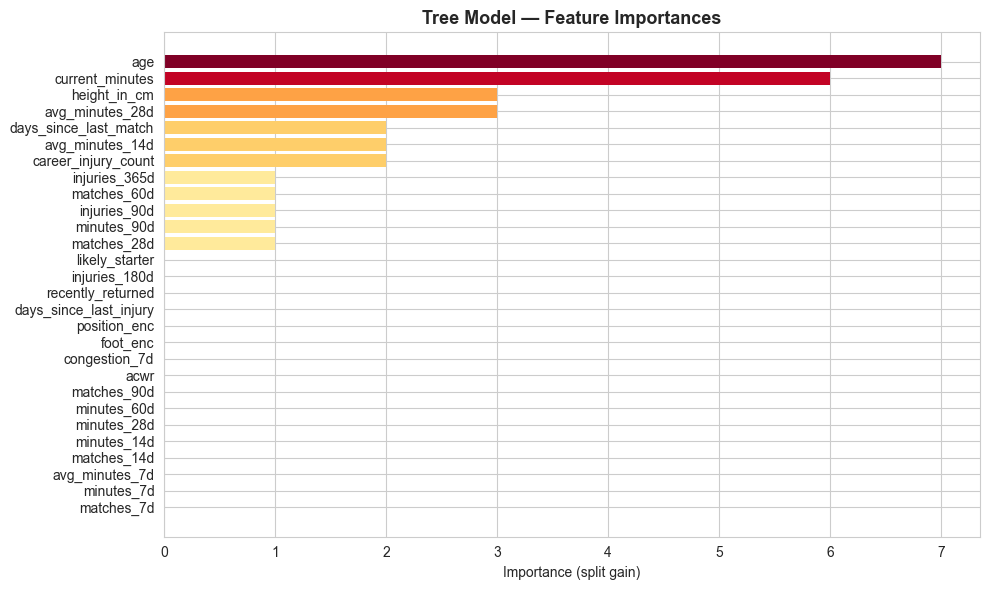

In [31]:
# 12.3 Feature importance plots (separate figures)

# ── Logistic Regression Coefficients ─────────────────────────────────
lr_coefs_sorted = lr_coefs.sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in lr_coefs_sorted['coefficient']]
ax.barh(lr_coefs_sorted['feature'], lr_coefs_sorted['coefficient'], color=colors, edgecolor='none')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title('Logistic Regression — Standardised Coefficients', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient (positive → increases risk)')
plt.tight_layout()
plt.savefig('../notebooks/fig_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tree Model Feature Importances ───────────────────────────────────
if HAS_LGB:
    imp_df = pd.DataFrame({
        'feature': ALL_FEATURE_COLS,
        'importance': lgb_model.feature_importances_ if hasattr(lgb_model, 'feature_importances_') else rf.feature_importances_
    }).sort_values('importance')
else:
    imp_df = rf_importance.sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 6))
norm_imp = imp_df['importance'] / imp_df['importance'].max()
colors = plt.cm.YlOrRd(norm_imp.values)
ax.barh(imp_df['feature'], imp_df['importance'], color=colors, edgecolor='none')
ax.set_title('Tree Model — Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (split gain)')
plt.tight_layout()
plt.savefig('../notebooks/fig_tree_importance.png', dpi=150, bbox_inches='tight')
plt.show()

=== PLAYER-LEVEL RISK HEATMAPS ===



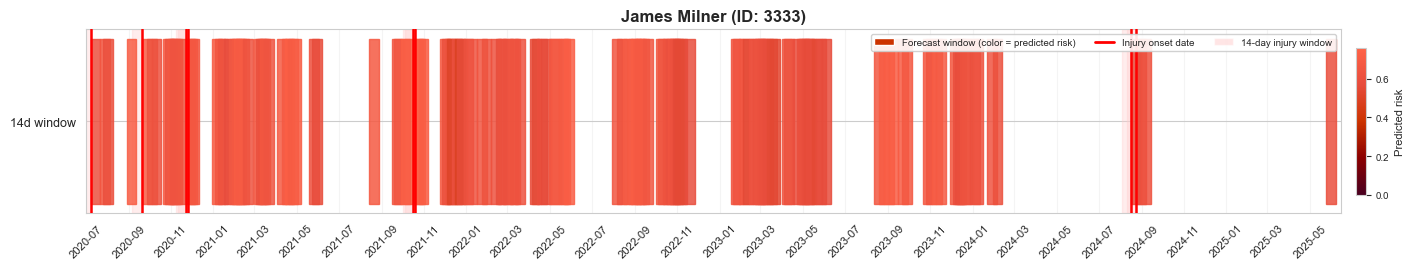

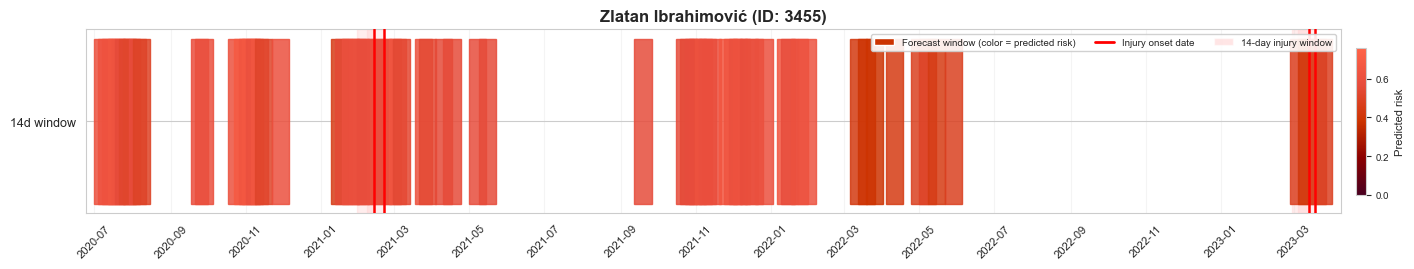

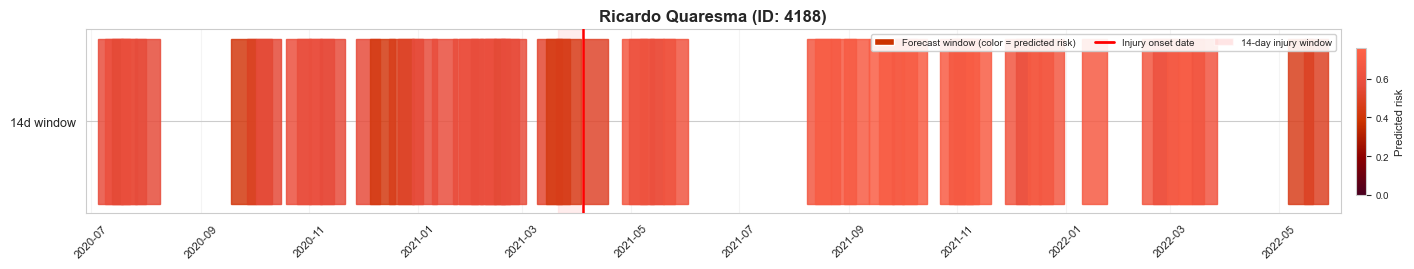

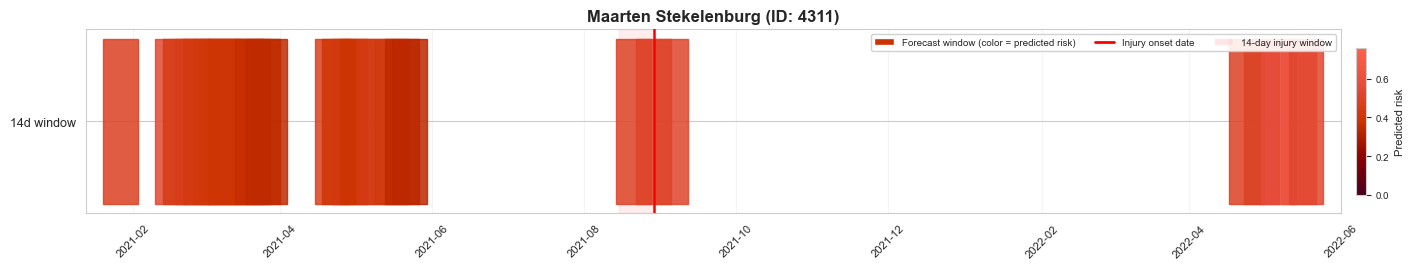

In [35]:
# 12.4 Player-level 14-day injury risk forecast windows
# Each player gets a timeline showing predicted risk windows and actual injuries.

from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from datetime import timedelta as td

print("=== PLAYER-LEVEL RISK HEATMAPS ===\n")

# Custom colormap: dark maroon (low) → orange-red → bright red (high)
risk_cmap = LinearSegmentedColormap.from_list(
    "risk", ["#4a0020", "#8b0000", "#cc3300", "#e74c3c", "#ff6347"]
)

# Find players in test set who had at least one injury event
test_injured_players = test_df[test_df['injury_14d'] == 1]['player_id'].unique()
sample_players = []
for pid in test_injured_players:
    player_data = test_df[test_df['player_id'] == pid]
    if len(player_data) >= 10:
        sample_players.append(pid)
    if len(sample_players) >= 4:
        break

base_rate = y_test.mean()
norm = Normalize(vmin=0, vmax=max(test_df['pred_prob'].quantile(0.99), base_rate * 5))

for pid in sample_players:
    pdata = test_df[test_df['player_id'] == pid].sort_values('date').copy()
    player_name = pdata['player_name'].iloc[0] if 'player_name' in pdata.columns else f"Player {pid}"
    dates = pd.to_datetime(pdata['date'].values)
    probs = pdata['pred_prob'].values

    fig, ax = plt.subplots(figsize=(16, 2.8))

    # ── 14-day injury windows (light pink background) ───────────────
    injury_dates = pdata[pdata['injury_14d'] == 1]['date'].values
    injury_dates = pd.to_datetime(injury_dates)
    for d in injury_dates:
        window_start = d - td(days=14)
        ax.axvspan(window_start, d, color='#ffcccc', alpha=0.35, zorder=1)

    # ── Forecast bars: each match → 14-day window colored by risk ───
    for date_val, prob in zip(dates, probs):
        rect = plt.Rectangle(
            (mdates.date2num(date_val), 0.05), 14, 0.9,
            color=risk_cmap(norm(prob)), alpha=0.85, zorder=2
        )
        ax.add_patch(rect)

    # ── Injury onset lines ──────────────────────────────────────────
    for d in injury_dates:
        ax.axvline(x=mdates.date2num(d), color='red', linewidth=1.8, zorder=3)

    # Axis formatting
    ax.set_xlim(mdates.date2num(dates.min() - td(days=7)),
                mdates.date2num(dates.max() + td(days=21)))
    ax.set_ylim(0, 1)
    ax.set_yticks([0.5])
    ax.set_yticklabels(['14d window'], fontsize=9)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_title(f'{player_name} (ID: {pid})', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.2)

    # ── Legend ──────────────────────────────────────────────────────
    legend_elements = [
        mpatches.Patch(facecolor=risk_cmap(0.5), label='Forecast window (color = predicted risk)'),
        plt.Line2D([0], [0], color='red', linewidth=2, label='Injury onset date'),
        mpatches.Patch(facecolor='#ffcccc', alpha=0.5, label='14-day injury window'),
    ]
    ax.legend(handles=legend_elements, fontsize=7, loc='upper right',
              framealpha=0.9, ncol=3)

    # ── Colorbar ────────────────────────────────────────────────────
    sm = plt.cm.ScalarMappable(cmap=risk_cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, pad=0.01, aspect=15, shrink=0.8)
    cbar.set_label('Predicted risk', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.savefig(f'../notebooks/fig_risk_{pid}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print()

if not sample_players:
    print("Not enough test-set players with injuries and sufficient data for individual plots.")

---
# 13. Production-Readiness Verdict

In [33]:
# 13.1 Automated verdict based on metrics
print("=" * 70)
print("  PRODUCTION-READINESS VERDICT")
print("=" * 70)

test_prev = y_test.mean()
test_pr_auc = average_precision_score(y_test, best_test_prob)
test_roc_auc = roc_auc_score(y_test, best_test_prob)
test_brier = brier_score_loss(y_test, best_test_prob)
pr_auc_ratio = test_pr_auc / test_prev  # how many times better than random

print(f"\n  Best model: {best_name}")
print(f"  Test ROC-AUC: {test_roc_auc:.4f}")
print(f"  Test PR-AUC:  {test_pr_auc:.4f}")
print(f"  Base rate:    {test_prev:.4f}")
print(f"  PR-AUC / Base rate ratio: {pr_auc_ratio:.2f}x")
print(f"  Brier Skill Score: {brier_skill:.4f}")

print(f"\n--- Assessment ---")

# 1. Ranking utility
if pr_auc_ratio > 3:
    rank_verdict = "MODERATE: Model provides some ranking ability"
elif pr_auc_ratio > 1.5:
    rank_verdict = "WEAK: Model ranks slightly better than random"
else:
    rank_verdict = "POOR: Model ranking is barely above random"
print(f"  Ranking:           {rank_verdict}")

# 2. Probability estimation
if abs(brier_skill) < 0.01:
    prob_verdict = "POOR: No better than predicting base rate for everyone"
elif brier_skill > 0.05:
    prob_verdict = "MODERATE: Some improvement over base-rate prediction"
else:
    prob_verdict = "WEAK: Marginal improvement over base-rate prediction"
print(f"  Probability est.:  {prob_verdict}")

# 3. Operational alerting
# Check if any threshold achieves precision > 2x base rate with > 10% recall
good_thresholds = threshold_df[
    (threshold_df['precision'] > 2 * test_prev) &
    (threshold_df['recall'] > 0.10) &
    (threshold_df['alerts_per_week'] < 10)
]
if len(good_thresholds) > 0:
    alert_verdict = "POSSIBLY: Some thresholds achieve meaningful precision at tolerable volume"
else:
    alert_verdict = "NO: No threshold combines adequate precision with tolerable alert volume"
print(f"  Operational alert: {alert_verdict}")

# 4. Overall
if pr_auc_ratio > 3 and brier_skill > 0.05 and len(good_thresholds) > 0:
    overall = "CONDITIONALLY READY — worth piloting with caveats"
elif pr_auc_ratio > 1.5:
    overall = "NOT PRODUCTION-READY — has weak signal but insufficient for real decisions"
else:
    overall = "NOT PRODUCTION-READY — insufficient signal for operational use"
print(f"\n  *** OVERALL: {overall} ***")

print(f"\n--- Detailed Rationale ---")
print("""
The model built from publicly available Transfermarkt data uses only:
  - Match appearance history (minutes, matches, congestion)
  - Injury history (prior injury count, recency, recent return)
  - Basic demographics (age, height, position, foot)

These are INDIRECT PROXIES for actual injury risk factors. The critical
missing inputs are:
  - GPS/tracking load (actual physical demands)
  - Training load and session-level data
  - Internal load markers (RPE, wellness, fatigue, sleep)
  - Medical screening results
  - Precise injury mechanism and tissue-level detail
  - Return-to-play protocol data

Without these, the model primarily captures:
  1. Base-rate variation (some players play more and get more injuries)
  2. Injury recurrence (players with past injuries are more likely to re-injure)

This is useful knowledge but it is NOT sufficient for a reliable daily
alerting system that a medical department would trust for load-management
decisions.
""")

  PRODUCTION-READINESS VERDICT

  Best model: Random Forest
  Test ROC-AUC: 0.6686
  Test PR-AUC:  0.0254
  Base rate:    0.0122
  PR-AUC / Base rate ratio: 2.08x
  Brier Skill Score: -18.1098

--- Assessment ---
  Ranking:           WEAK: Model ranks slightly better than random
  Probability est.:  WEAK: Marginal improvement over base-rate prediction
  Operational alert: POSSIBLY: Some thresholds achieve meaningful precision at tolerable volume

  *** OVERALL: NOT PRODUCTION-READY — has weak signal but insufficient for real decisions ***

--- Detailed Rationale ---

The model built from publicly available Transfermarkt data uses only:
  - Match appearance history (minutes, matches, congestion)
  - Injury history (prior injury count, recency, recent return)
  - Basic demographics (age, height, position, foot)

These are INDIRECT PROXIES for actual injury risk factors. The critical
missing inputs are:
  - GPS/tracking load (actual physical demands)
  - Training load and session-level da

---
# 14. Recommended Next Steps

Ordered by expected impact on model quality.

## Priority 1: Better Data Sources (High Impact)

| Data Source | Why It Matters | Expected Impact |
|---|---|---|
| **GPS / tracking load** | Total distance, high-speed running, accelerations — the primary physical stressors | **Critical** — most published injury prediction models rely on this |
| **Training session data** | Training load is the majority of total load; match-only data misses 60-80% of exposure | **Critical** |
| **Internal load (RPE, wellness, sleep, soreness)** | Captures individual response to load, fatigue accumulation | **High** |
| **Better medical records** | Precise injury dates, mechanism (contact vs non-contact), tissue type, severity grading | **High** |
| **Return-to-play detail** | Structured return phases, readiness scores, medical clearance dates | **Moderate** |

## Priority 2: Better Target Definition (Medium Impact)

- Use a **survival / time-to-event** framework instead of binary classification
- Consider a **multi-state model** (healthy → at-risk → injured → recovering)
- Separate **contact** from **non-contact** injuries (only non-contact are predictable)
- Define severity tiers (minor / moderate / severe) for differentiated alerting
- Consider muscle-group-specific models rather than "any musculoskeletal injury"

## Priority 3: Modeling Improvements (Lower Impact Without Better Data)

- **Survival models** (Cox, discrete-time hazard) if censoring is meaningful
- **Recurrent event models** for players with multiple injury episodes
- **Player-specific baselines** (random effects / mixed models)
- **Probability calibration** with Venn-Abers or conformal prediction for uncertainty
- **Rolling-origin cross-validation** for more robust temporal validation
- **Alert policy optimisation** to find the Pareto-optimal precision-recall-volume tradeoff

## Priority 4: Operational Integration

- Design the alert output as a **ranked list** (top-N risky players) rather than binary flags
- Define **escalation tiers** (watch / screen / rest) with different thresholds
- Build a **monitoring dashboard** that tracks model calibration drift over time
- Establish a **feedback loop** where medical staff report actual injuries to update the model

## Honest Assessment

The fundamental limitation is **feature poverty**. No amount of model sophistication will compensate for the absence of physical load data. The published literature on injury prediction in elite football consistently shows that:

1. Match exposure alone is a weak predictor
2. GPS/tracking metrics (especially high-speed running distance, acceleration load) are the most important features
3. Acute:chronic workload ratios derived from training + match load provide the best signal
4. Even with full data, daily injury prediction remains extremely difficult (PR-AUC rarely exceeds 0.10-0.15)

This notebook demonstrates that the available open data cannot support a credible daily injury risk alerting system. It can, however, serve as a **structural foundation** — the pipeline, validation framework, and evaluation methodology are sound and can be reused when better data becomes available.